# Automatización de Cambio V para pasos 0.n, 0.0n, 0.00n, 0.000n, con n=0,1,2,...,9


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import fsolve
import time
from IPython.display import display, Markdown

pasos = [round(x, 4) for x in (
    list(np.arange(0.9, 0.09, -0.1)) +
    list(np.arange(0.09, 0.009, -0.01)) +
    list(np.arange(0.009, 0.0009, -0.001)) +
    list(np.arange(0.0009, 0.00009, -0.0001)) +
    [0.0001]
)]
m = 1
#importación del archivo de comparación: La ruta tiene que ser cambiada de acuerdo la ruta de los datos



comp_1 = np.load(r"C:\Users\isaac\Articulo\Arrays\datos1.npy")

#LISTA DE FUNCIONES
def derivar_polinomio(coeficientes, x):
    y_derivada = np.zeros_like(x)
    for i in range(1, len(coeficientes)):
        y_derivada += i * coeficientes[i] * (x ** (i - 1))
    return y_derivada

def dsigma_1(b, db, theta):
    ds = []
    theta_1 = []
    epsilon = 1e-10  # Umbral para evitar divisiones por valores muy pequeños
    for i in range(len(b)):
        if np.abs(np.sin(theta[i])) > epsilon and np.abs(db[i]) > epsilon:
            aux = b[i] / np.sin(theta[i]) * (np.abs(db[i]))
            ds.append(aux)
            theta_1.append(theta[i])
    return np.array(ds), np.array(theta_1)

def f(m, u, R):
    return 1-2*m*((1-u**2)/R)

def integrando(u, R, b, E):
    fu = f(m, u, R)
    un = R**2 / (4*u**2 * b**2) - ((1-u**2)**2/(4*u**2))*fu
    # Para evitar valores negativos en la raíz
    if un <= 0:
        return 0
    return 1/np.sqrt(un)
def coeficientes_cubica(b, m):
    # Ecuación cubica: r^3 - b^2*r + 2mb^2 = 0
    return [1, 0, -b**2, 2*m*b**2]
def calcular_coeficientes(x, y, err, grad):
    n = grad
    #matriz A contiene potencias de x 
    A = np.zeros((n, n))
    #vector b contiene suma de productos de y potencias de x 
    b = np.zeros(n)

    for i in range(n):
        for j in range(n):
            A[i, j] = 2*np.sum((x**(i+j))/err)
        b[i] = 2 * np.sum((y * x**i)/err) 
    coef = np.linalg.solve(A, b)
    return coef

def evaluar_polinomio(coeficientes, x):
    y = np.zeros_like(x)
    for i in range(len(coeficientes)):
        y += coeficientes[i] * (x ** i)
    return y
def automatizacion(paso):
    #Definición de las constantes de inicio y fin para valores de b
    inicio = 3 * (3**(1/2)) * m
    fin = 10 * m
    valores_b = np.arange(inicio, fin, paso)

    valores_r_minima = []

    #Para cada valor de se resuelve ecuacion cubica para u
    for b in valores_b:
        coefs = coeficientes_cubica(b, m)
        # Se encuentran todas las raíces (reales y complejas)
        raices = np.roots(coefs)
        # Se Filtran las raíces reales positivas
        raices_reales_positivas = raices[np.isreal(raices) & (raices.real > 0)].real
        # Seleccionar la raíz positiva más pequeña si existe
        if len(raices_reales_positivas) > 0:
            raiz_minima = max(raices_reales_positivas)
            valores_r_minima.append(raiz_minima)
        else:
            # Si no hay raíces positivas, agregar NaN
            valores_r_minima.append(np.nan)
    
    # Graficar los resultados (si se requiere apoyo visual descomentar esta sección)
    valores_r_minima = np.array(valores_r_minima)
    # plt.scatter(valores_b, valores_r_minima, label="Raíz positiva mínima", s=1)
    # plt.xlabel("b")
    # plt.ylabel("Raíz positiva mínima (U)")
    # plt.title("Raíz positiva mínima de la cúbica en función de b")
    # plt.legend()
    # plt.grid()
    # plt.show()

    E = 1.0
    valores_theta = []
    
    # Calculo la integral para cada b y R
    for b, R in zip(valores_b, valores_r_minima):
        valor_integral, _ = quad(integrando, 0, 1, args=(R,b,m))
        theta = 2*valor_integral -np.pi  # Se calcula theta
        valores_theta.append(theta)
    
    valores_theta = np.array(valores_theta)
    
    # Grafico theta vs b (Si se requiere apoyo visual descomentar esta sección)
    # plt.figure(figsize=(10, 6))
    # plt.plot(valores_theta, valores_b, label= 'θ vs b', color='purple')
    # #pongo el r para escribir theta simbolito
    # plt.title(r'Gráfica de θ  vs b (resultado númerico)')
    # plt.xlabel('θ')
    # plt.ylabel('Parámetro de impacto b')
    # plt.ylim(0, 11)
    # plt.xlim(0, 3.5)
    # plt.grid()
    # plt.legend()
    # plt.show()

    theta_values_2 = []
    b_values_2 = []
    
    #filtro de valores de theta, se seleccionan los del rango [0,pi] y sus respectivos b's, guardandolos en thetha_values_2 y b_values_2 
    for i in range (len(valores_theta)):
        if valores_theta[i] <= np.pi and valores_theta[i] >= 0:
          theta_values_2.append(valores_theta[i])
          b_values_2.append(valores_b[i])
    theta_values_2 = np.array(theta_values_2)
    b_values_2 = np.array(b_values_2)
    
    #se hace un array del mismo tamaño y forma que el array de los theta filtrados 
    #pero con valores 0.1 como para determinar el mismo error para todos los puntos con el mismo punto para el ajuste polinomial
    err = np.zeros_like(theta_values_2)
    for i in range(len(theta_values_2)):
        err[i] = 0.1
    coef_1 = calcular_coeficientes(theta_values_2, b_values_2,err,13)
    
    #crea un array con 10000 puntos desde 0 hasta pi
    x_2 = np.linspace(0,np.pi,10000)
    #evalua el ajuste polinomico en estos puntos 
    y_2 = evaluar_polinomio(coef_1,x_2) 
    #Si se requiere apoyo visual descomentar esta sección)
    
    # plt.plot(theta_values_2, b_values_2 ,'.',label='Datos Reales', color='darkred')
    # plt.plot(x_2,y_2, label = 'Ajuste realizado por mínimos cuadrádos', color = 'b')
    # plt.xlabel('Theta chica')
    # plt.ylabel('Parámetro de impacto b')
    # plt.legend()
    # plt.grid()

    # Calcular la derivada del polinomio ajustado
    y_derivada_2 = derivar_polinomio(coef_1, x_2)

    dsigma_2, theta_2 = dsigma_1(y_2, y_derivada_2, x_2)
    theta_2 = np.degrees(theta_2)
    
    plt.figure(figsize=(8, 6))
    plt.yscale('log')
    plt.plot(theta_2, dsigma_2, label=r'$\sigma(\theta)$ vs $\theta$', color='red')
    plt.title(f"Sección diferencial de dispersión para paso {paso}")
    plt.xlabel(r'$\theta$')
    plt.ylabel(r'$\sigma(\theta)$')
    plt.grid(True)
    plt.xlim(20,178)
    plt.ylim(1,10e2)
    plt.show()


    fin_tiempo = time.time()
    duracion = fin_tiempo - inicio_tiempo
    
    plt.figure(figsize=(8, 6))
    plt.yscale('log')
    plt.plot(theta_2, dsigma_2, label= 'Cambio v', color='red')
    plt.plot(comp_1[0], comp_1[1], label= 'Cambio u', color='blue')
    plt.title(f"Comparación de sección diferencial de dispersión para paso {paso}")
    plt.xlabel(r'$\theta$')
    plt.ylabel(r'$\sigma(\theta)$')
    plt.grid(True)
    plt.xlim(20,178)
    plt.ylim(1,10e2)
    plt.legend()
    plt.show()

    error_relativo_promedio = np.mean(np.abs(comp_1[1] - dsigma_2) / np.abs(comp_1[1]))
    error_porcentaje = error_relativo_promedio * 100


    theta_ref = comp_1[0]
    sigma_u = comp_1[1]
    sigma_v = dsigma_2 
        

    assert np.allclose(theta_2, theta_ref), "Los theta no coinciden"
        
    # Error relativo
    error_relativo = (np.abs(sigma_u - sigma_v) / np.abs(sigma_u))*100
        
    # Gráfica del error relativo
    plt.figure(figsize=(8, 5))
    plt.plot(theta_2, error_relativo, label="Error relativo") # para ver mejor las diferencias pequeñas
    plt.xlabel(r'$\theta$', fontsize=14)
    plt.ylabel("Error relativo (%)", fontsize=14)
    plt.title("Error relativo entre Cambio v y Cambio u")
    plt.grid(True)
    plt.legend()
    plt.ylim(0,2)
    plt.show()
    
    print(f"Error relativo promedio: {error_porcentaje:.5f} %")
    print(f"En paso: {paso}")
    return error_relativo_promedio, duracion

## **Ejecutando con paso = 0.9...**

C:\Users\isaac\AppData\Local\Temp\ipykernel_16960\3694082229.py:110: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  valor_integral, _ = quad(integrando, 0, 1, args=(R,b,m))


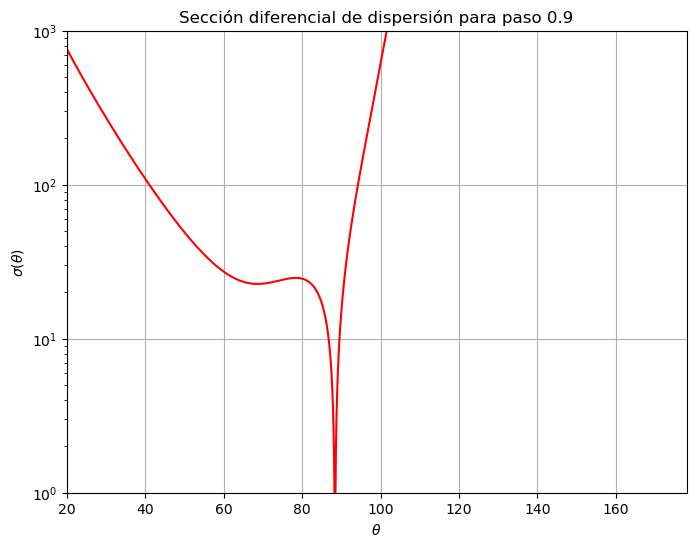

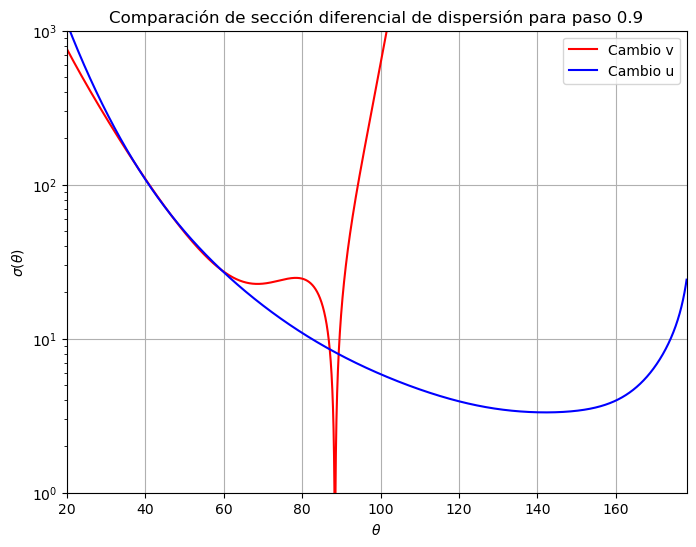

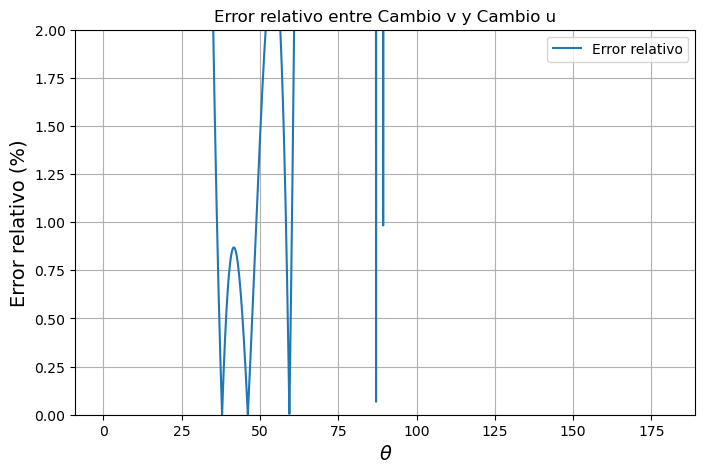

Error relativo promedio: 73273813065.05424 %
En paso: 0.9
Tiempo de ejecución para paso = 0.9: 0.7276 segundos


## **Ejecutando con paso = 0.8...**

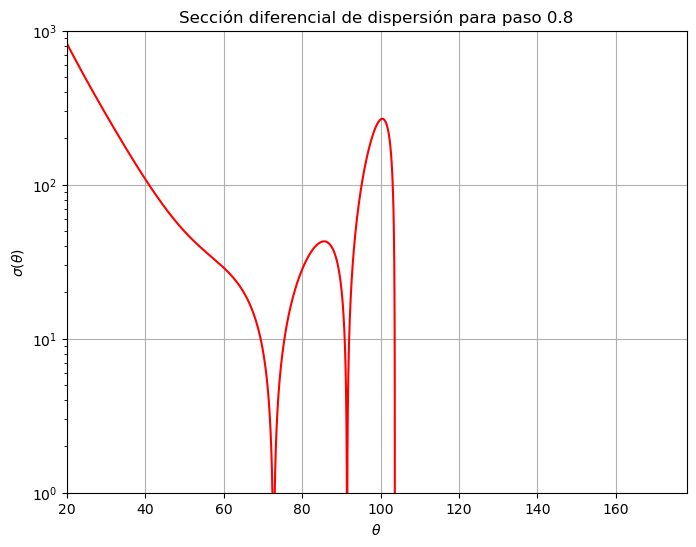

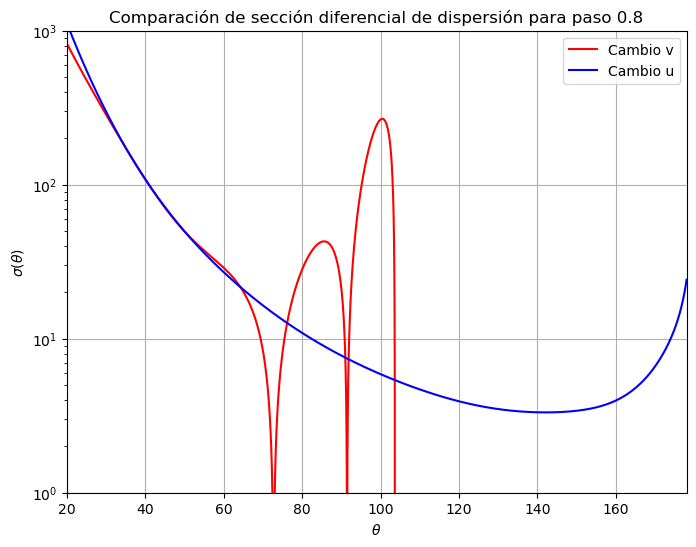

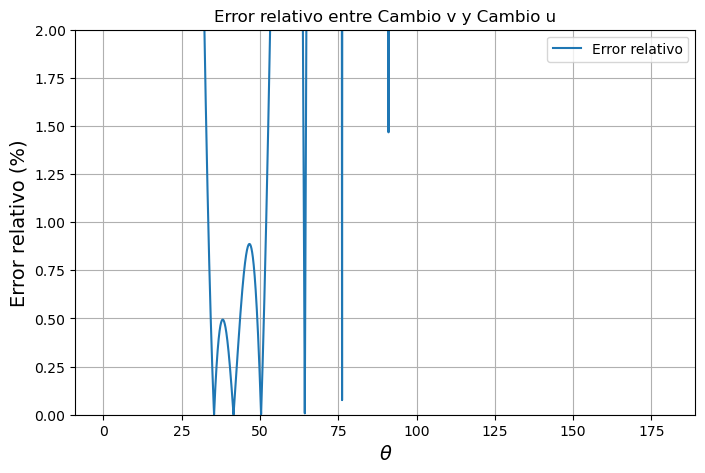

Error relativo promedio: 26727067084.90353 %
En paso: 0.8
Tiempo de ejecución para paso = 0.8: 0.6061 segundos


## **Ejecutando con paso = 0.7...**

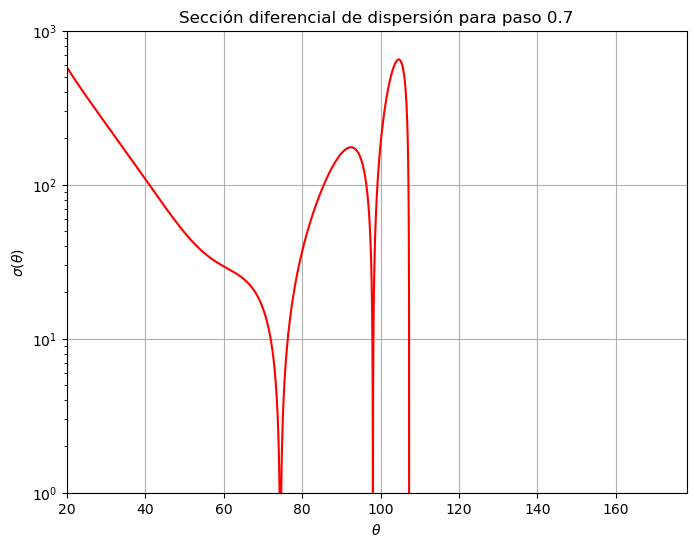

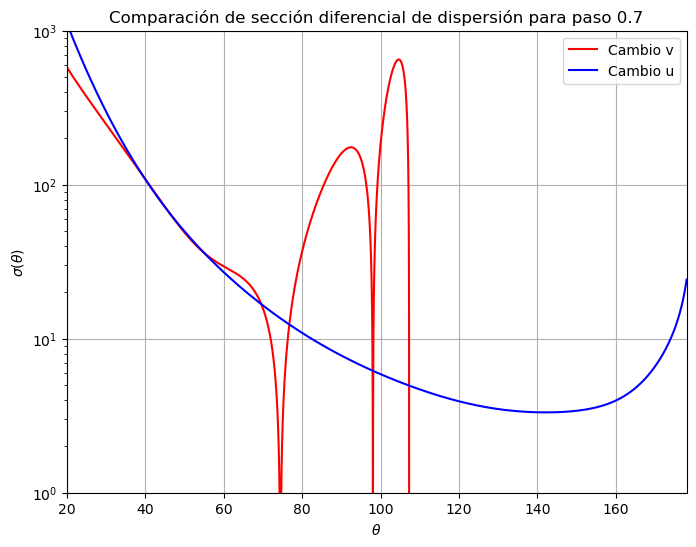

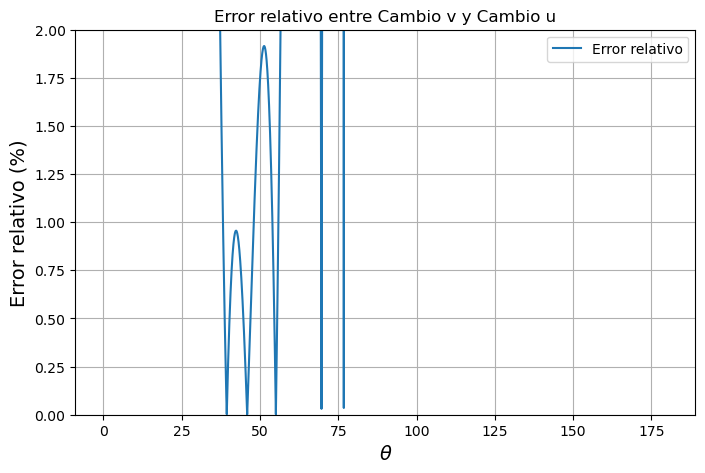

Error relativo promedio: 91376777396.14729 %
En paso: 0.7
Tiempo de ejecución para paso = 0.7: 0.7270 segundos


## **Ejecutando con paso = 0.6...**

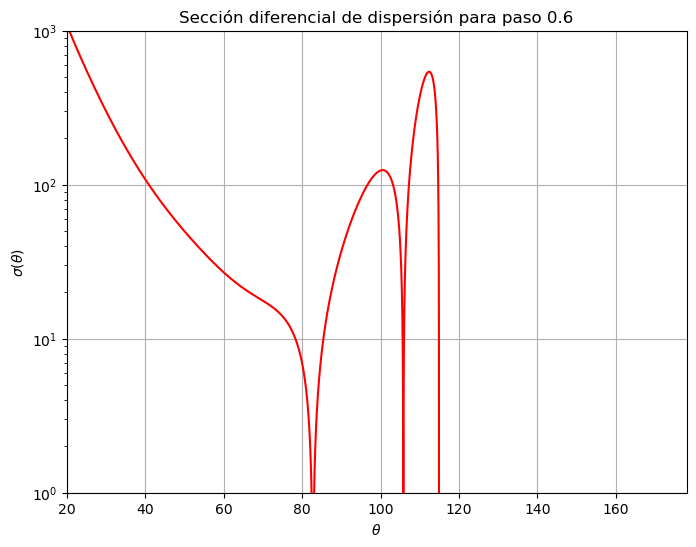

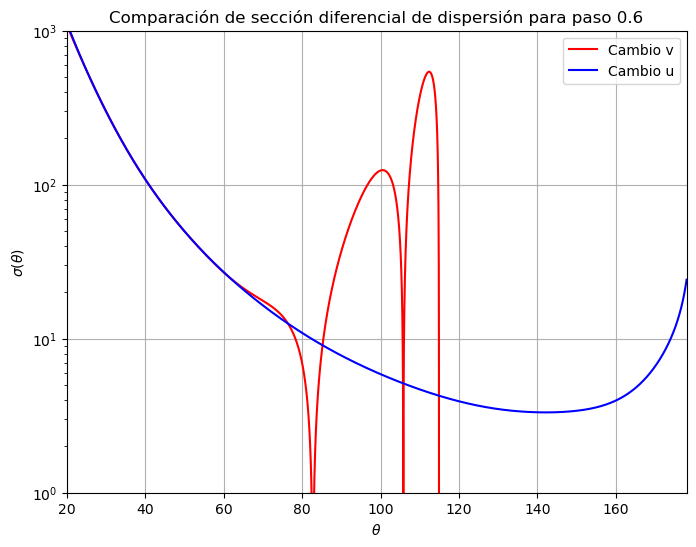

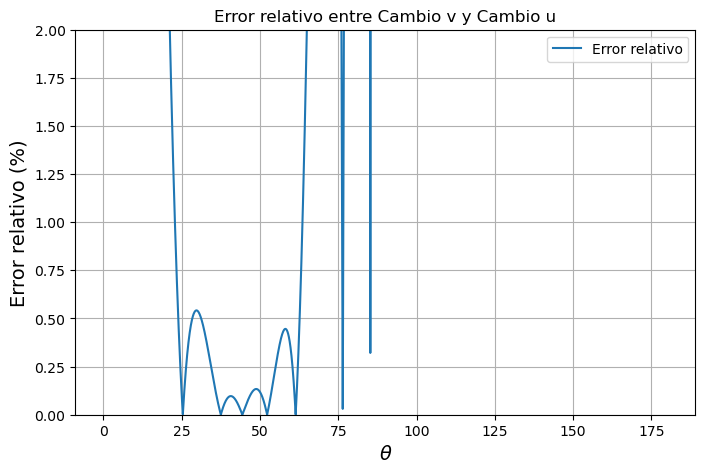

Error relativo promedio: 65193882595.00256 %
En paso: 0.6
Tiempo de ejecución para paso = 0.6: 0.7229 segundos


## **Ejecutando con paso = 0.5...**

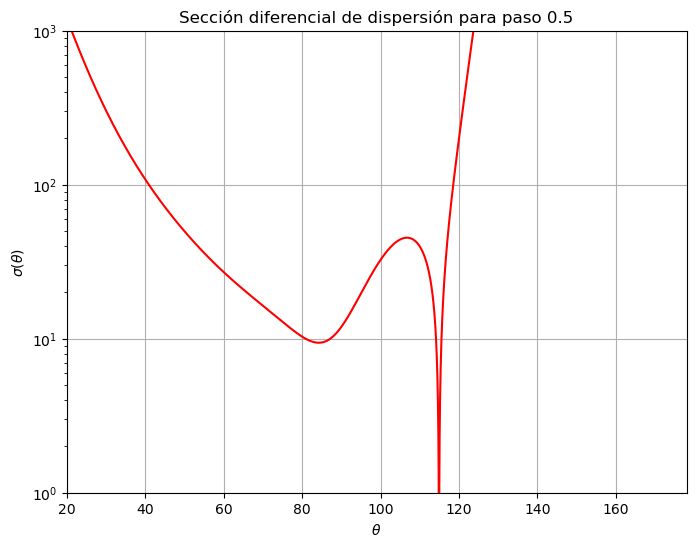

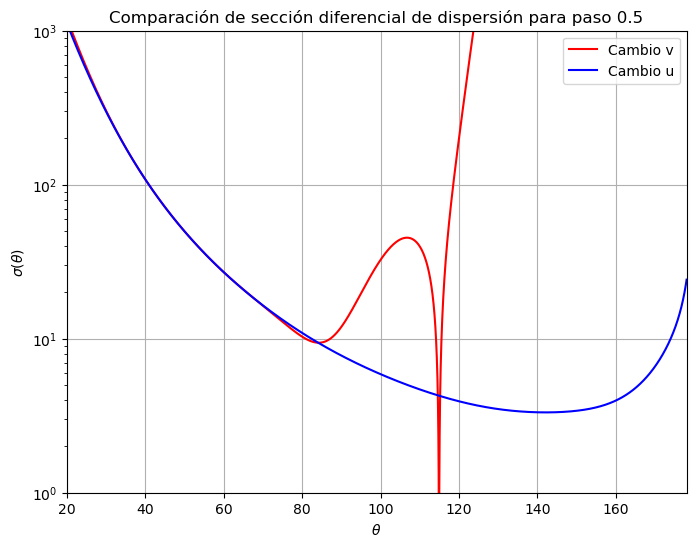

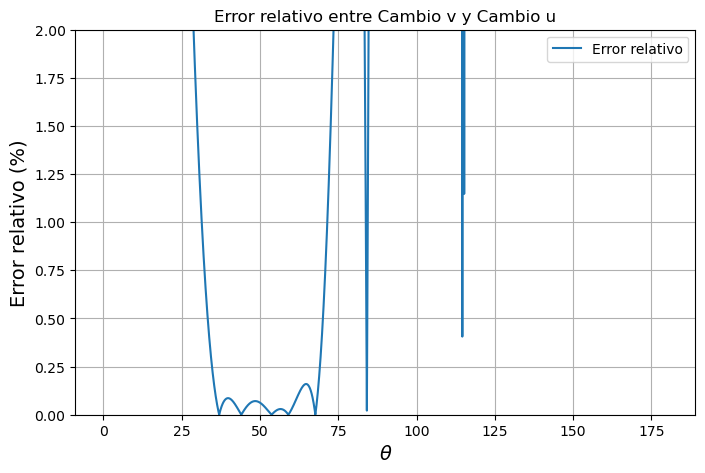

Error relativo promedio: 4702886007.27139 %
En paso: 0.5
Tiempo de ejecución para paso = 0.5: 0.7710 segundos


## **Ejecutando con paso = 0.4...**

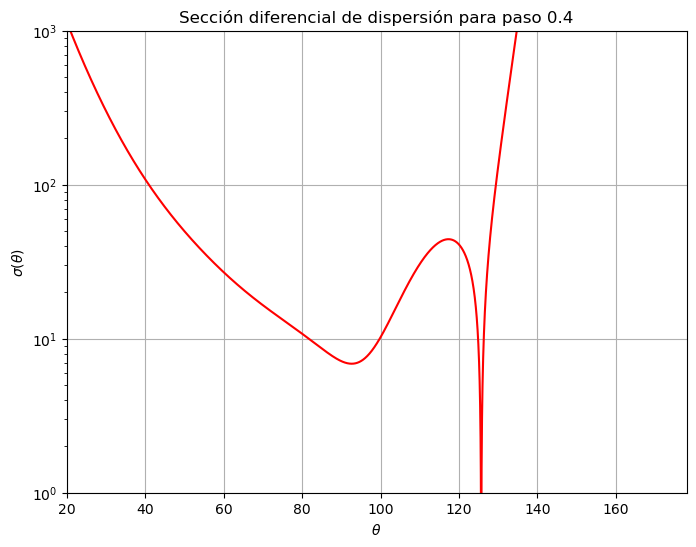

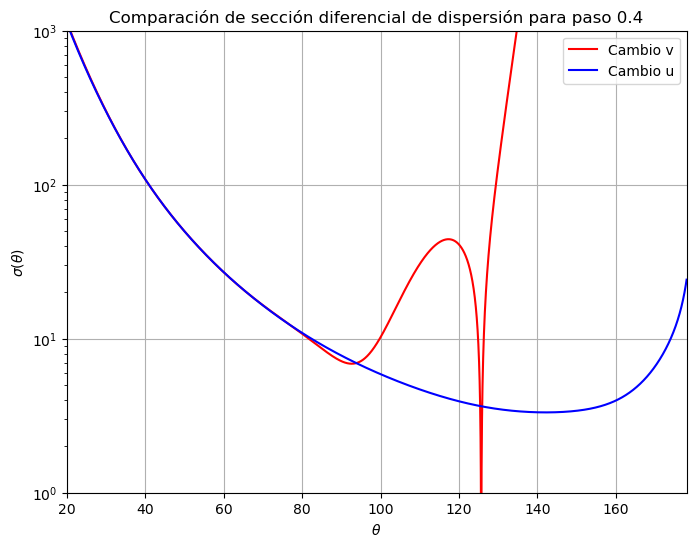

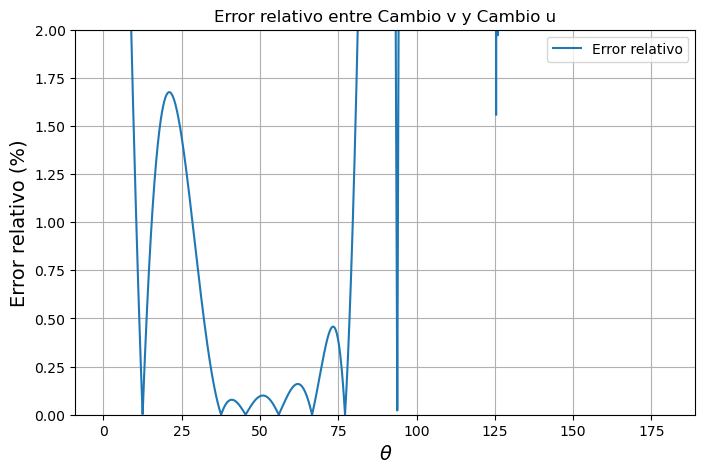

Error relativo promedio: 322373810.17318 %
En paso: 0.4
Tiempo de ejecución para paso = 0.4: 0.7984 segundos


## **Ejecutando con paso = 0.3...**

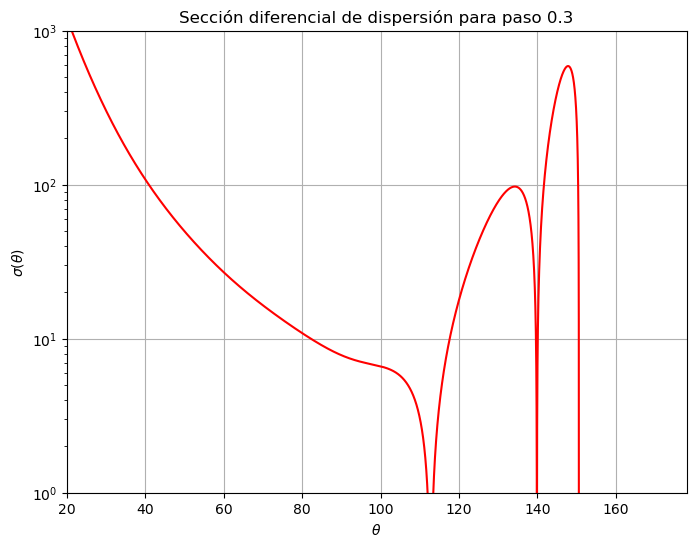

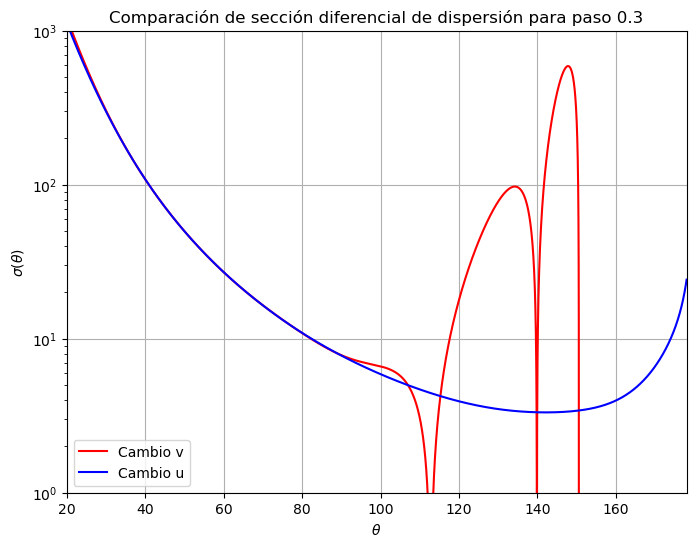

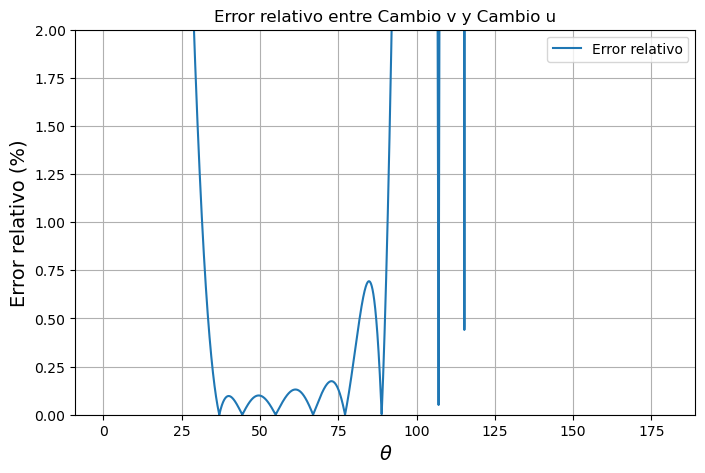

Error relativo promedio: 16213896.71469 %
En paso: 0.3
Tiempo de ejecución para paso = 0.3: 0.7711 segundos


## **Ejecutando con paso = 0.2...**

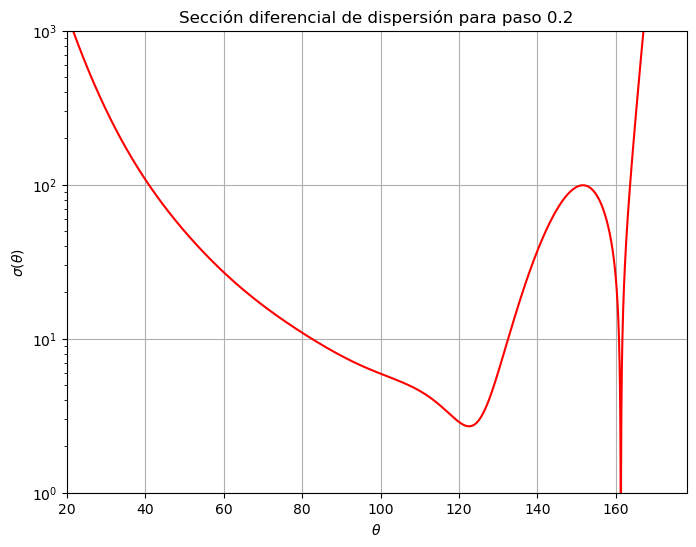

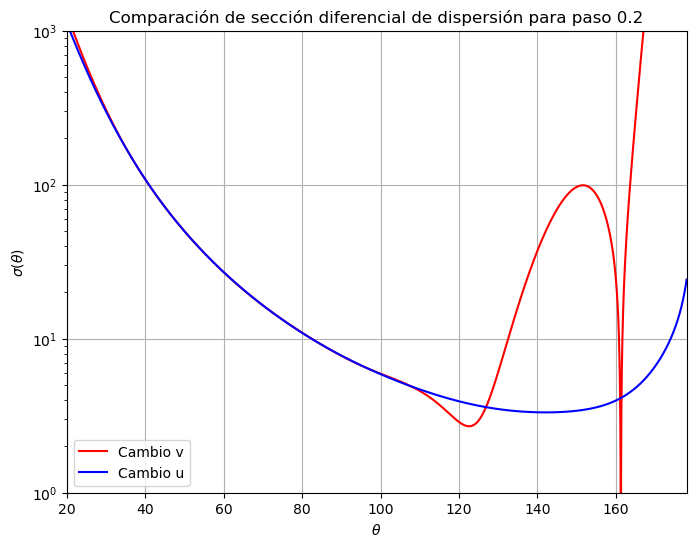

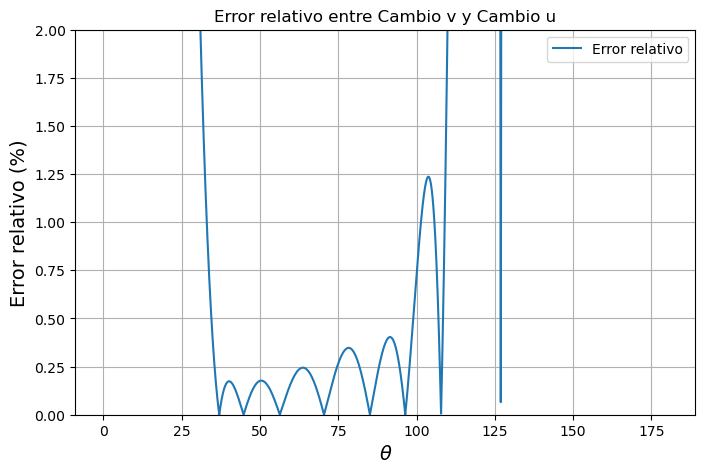

Error relativo promedio: 96381.81406 %
En paso: 0.2
Tiempo de ejecución para paso = 0.2: 0.9060 segundos


## **Ejecutando con paso = 0.1...**

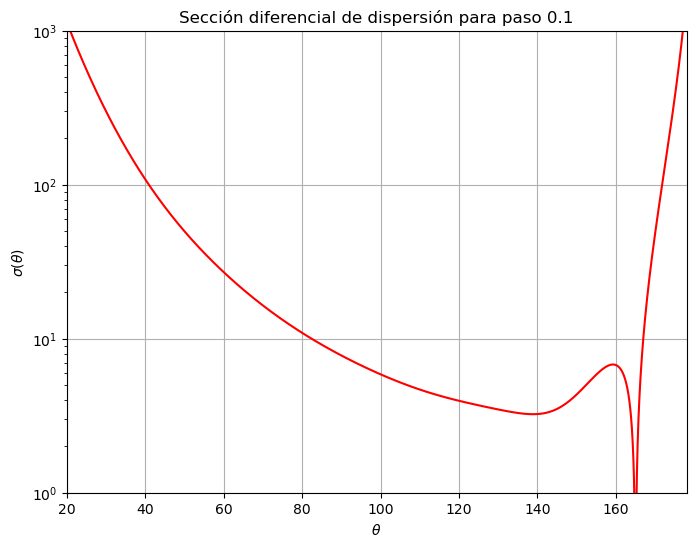

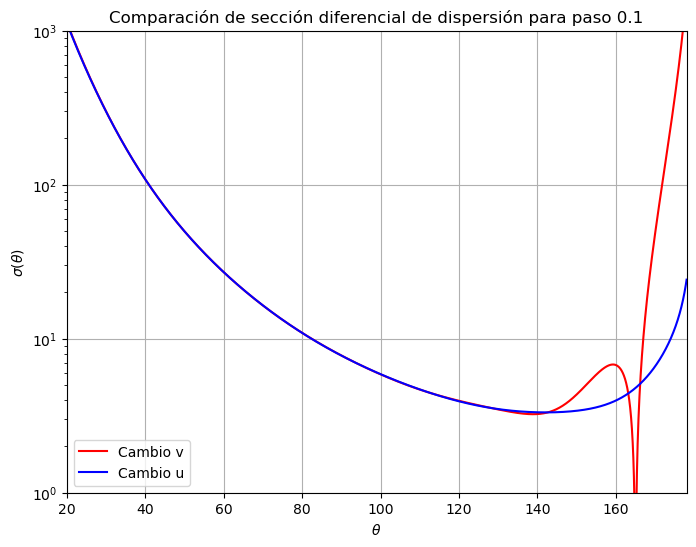

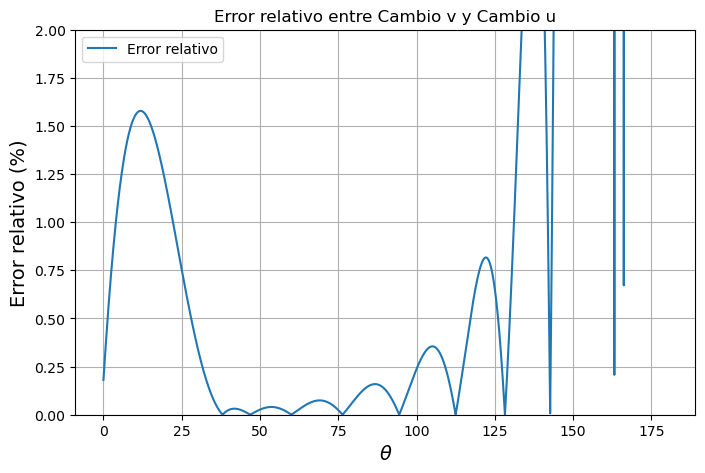

Error relativo promedio: 255.34432 %
En paso: 0.1
Tiempo de ejecución para paso = 0.1: 0.7250 segundos


## **Ejecutando con paso = 0.09...**

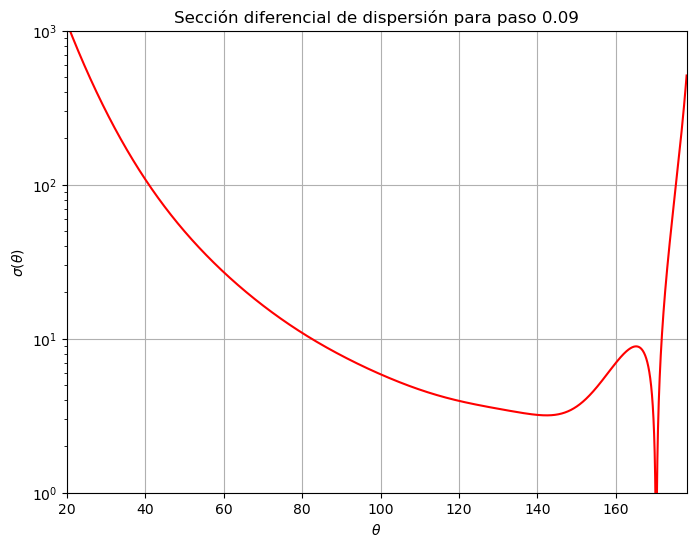

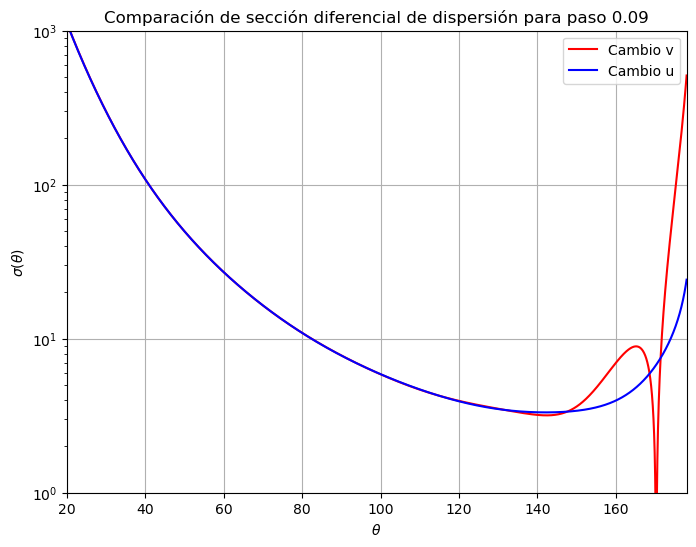

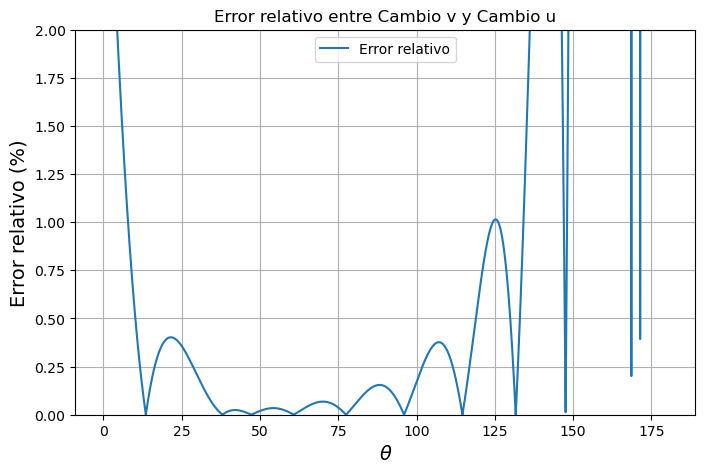

Error relativo promedio: 65.74776 %
En paso: 0.09
Tiempo de ejecución para paso = 0.09: 0.6330 segundos


## **Ejecutando con paso = 0.08...**

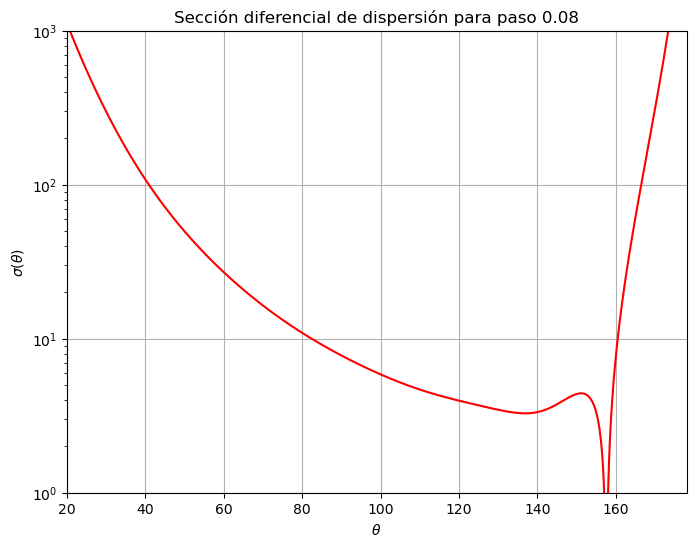

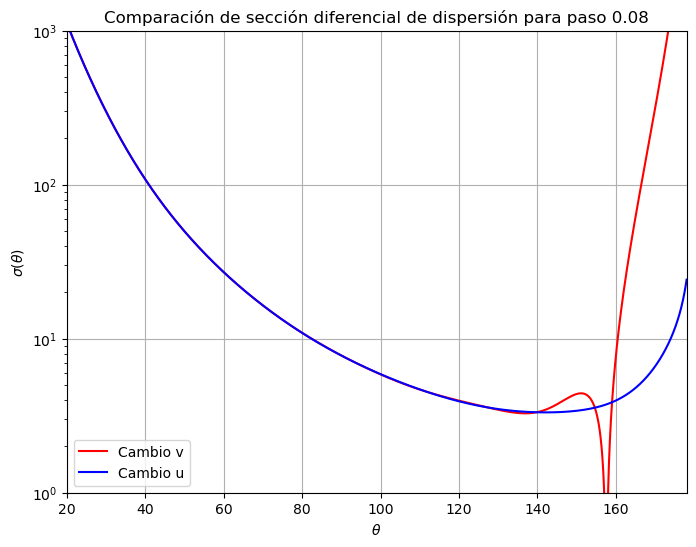

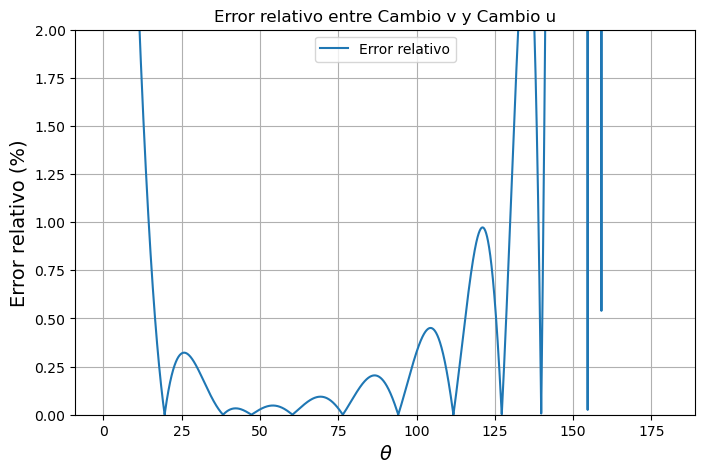

Error relativo promedio: 1426.00431 %
En paso: 0.08
Tiempo de ejecución para paso = 0.08: 0.8480 segundos


## **Ejecutando con paso = 0.07...**

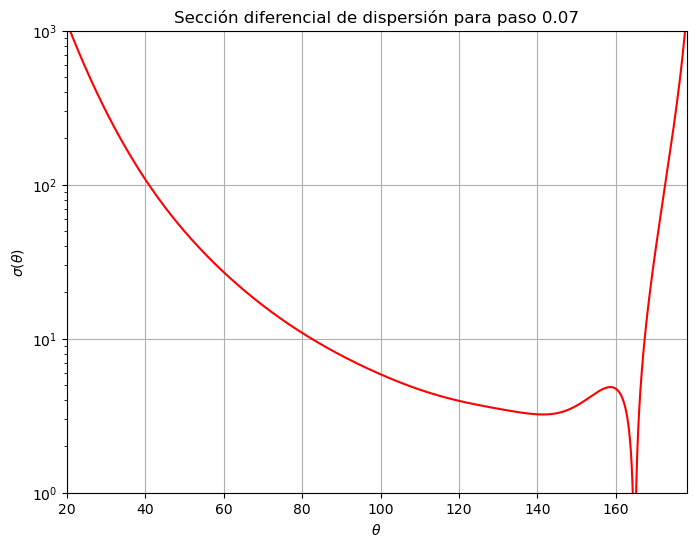

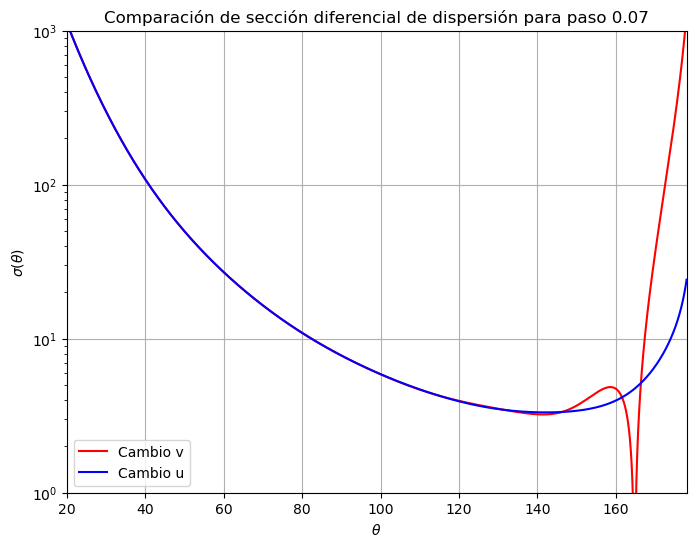

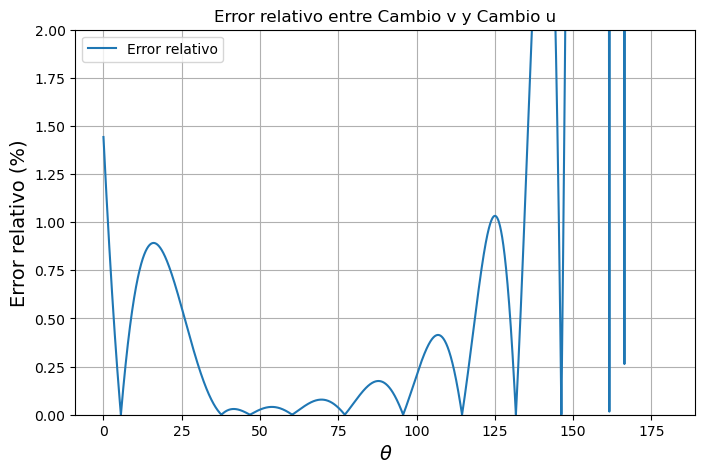

Error relativo promedio: 179.45427 %
En paso: 0.07
Tiempo de ejecución para paso = 0.07: 0.6751 segundos


## **Ejecutando con paso = 0.06...**

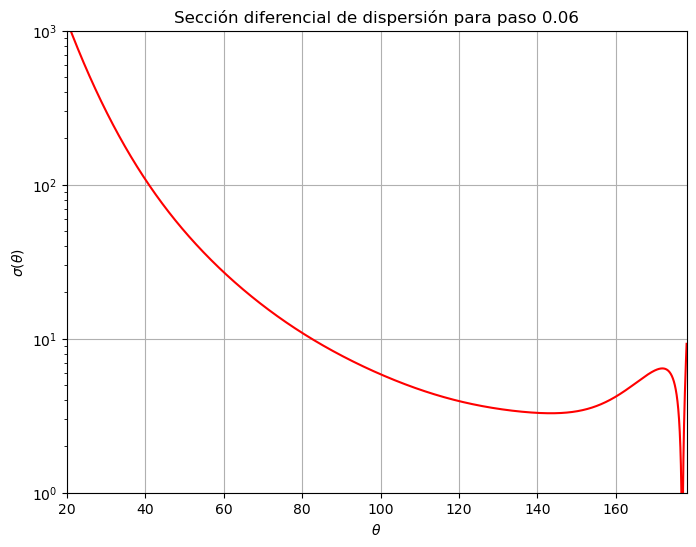

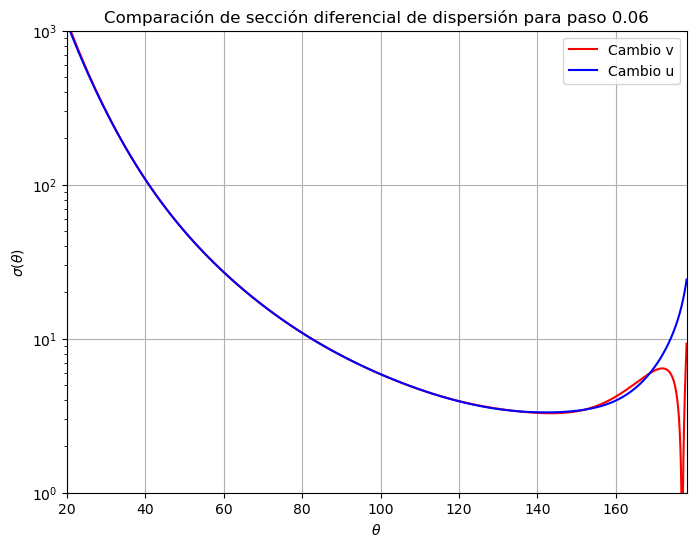

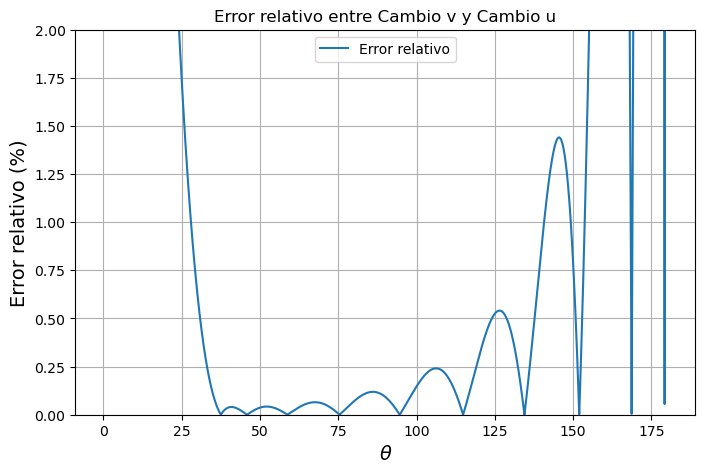

Error relativo promedio: 4.29390 %
En paso: 0.06
Tiempo de ejecución para paso = 0.06: 0.8184 segundos


## **Ejecutando con paso = 0.05...**

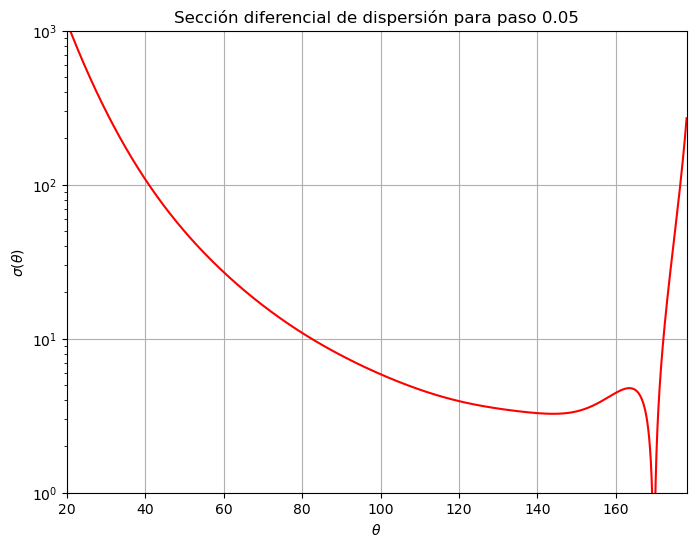

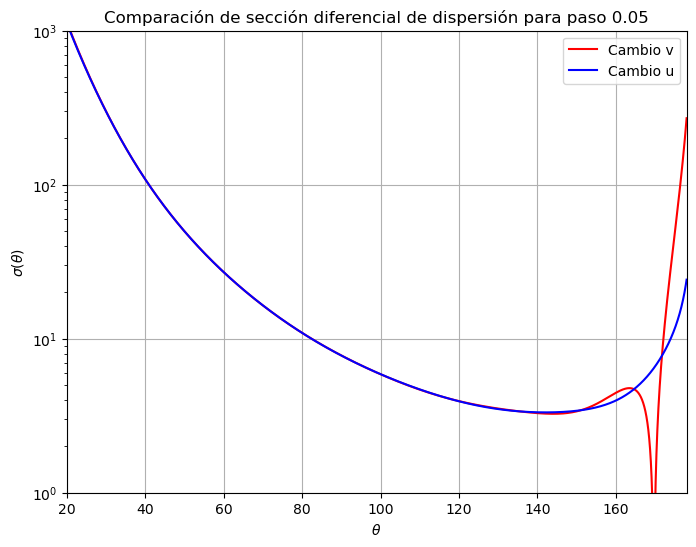

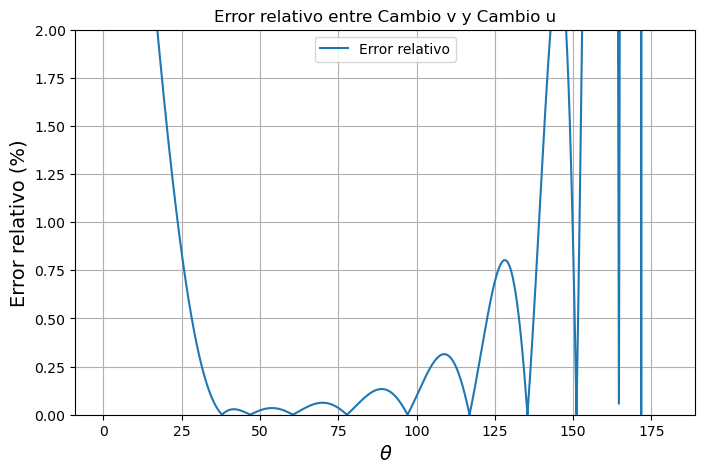

Error relativo promedio: 32.28429 %
En paso: 0.05
Tiempo de ejecución para paso = 0.05: 0.9019 segundos


## **Ejecutando con paso = 0.04...**

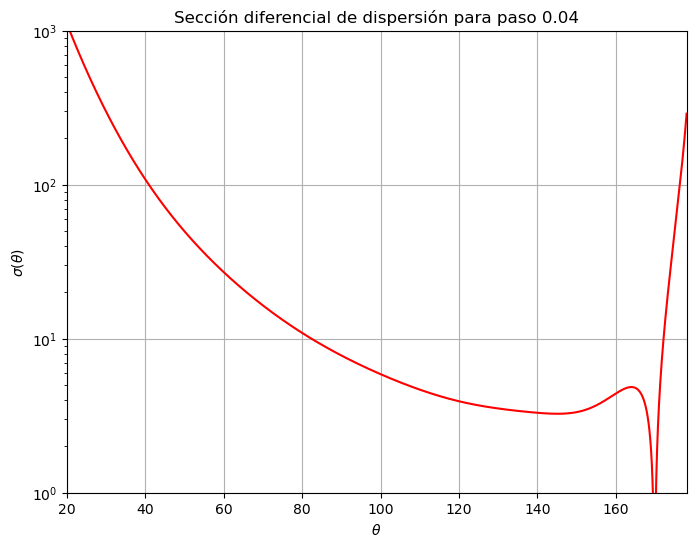

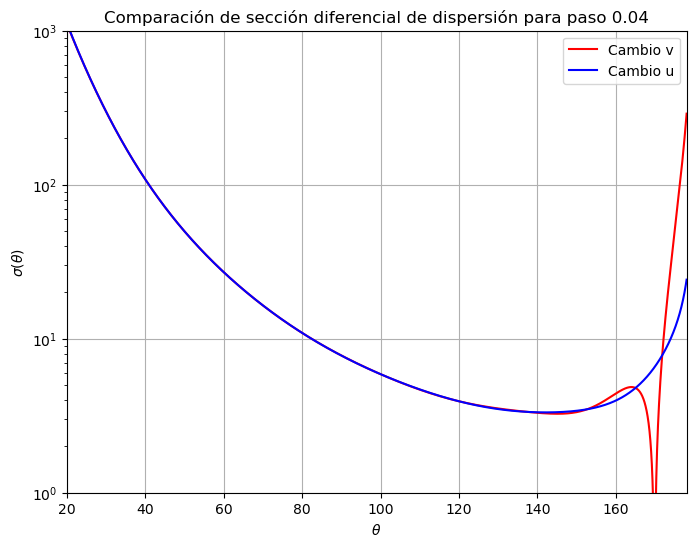

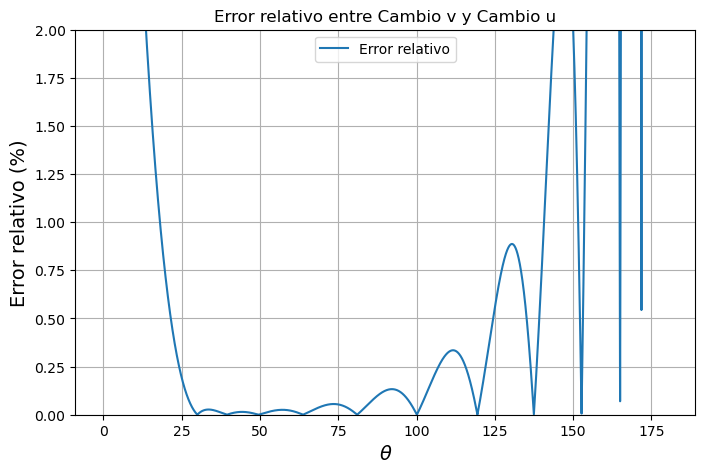

Error relativo promedio: 34.31447 %
En paso: 0.04
Tiempo de ejecución para paso = 0.04: 0.7908 segundos


## **Ejecutando con paso = 0.03...**

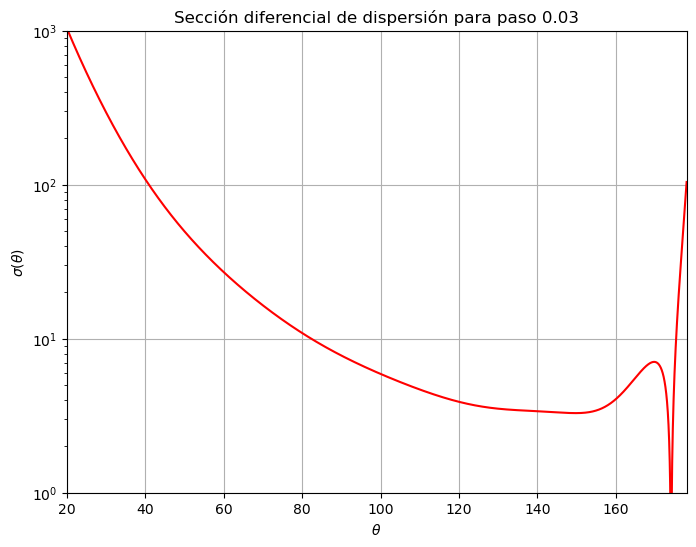

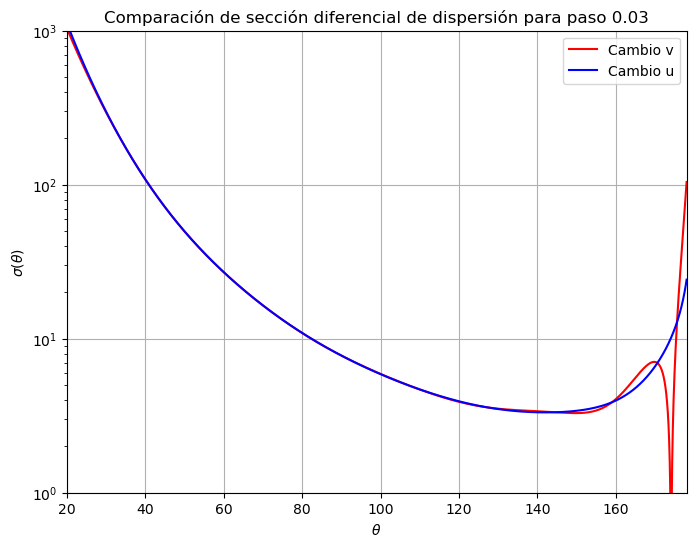

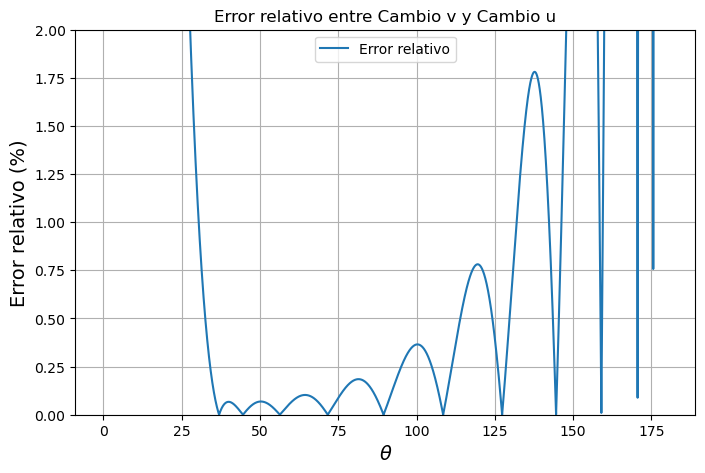

Error relativo promedio: 13.89619 %
En paso: 0.03
Tiempo de ejecución para paso = 0.03: 0.8197 segundos


## **Ejecutando con paso = 0.02...**

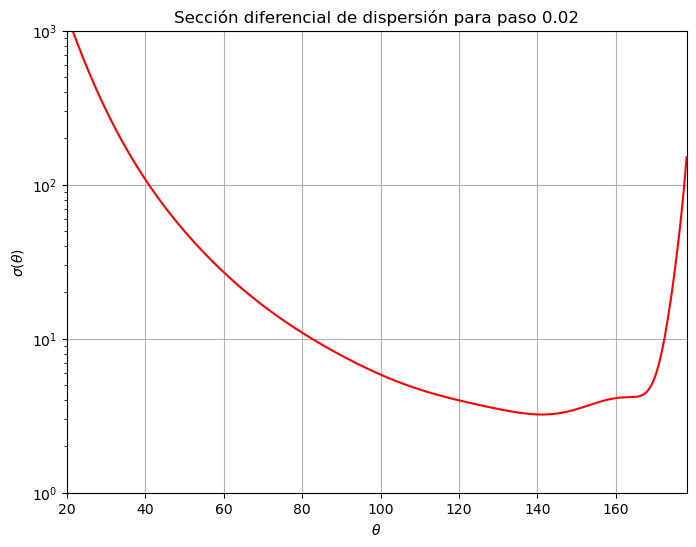

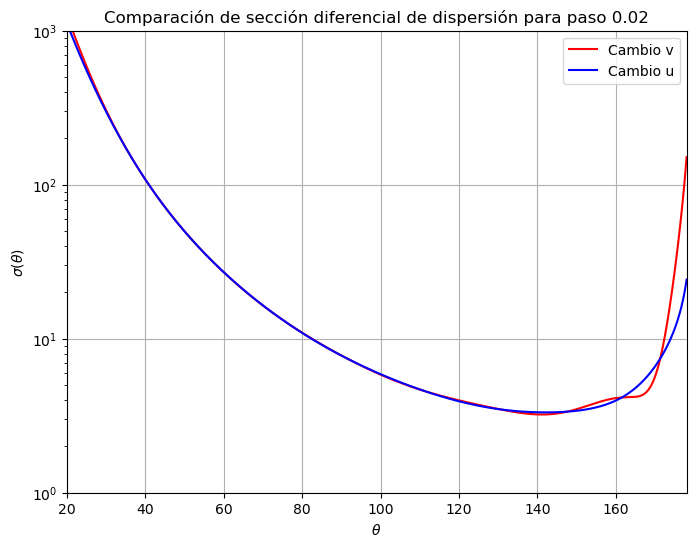

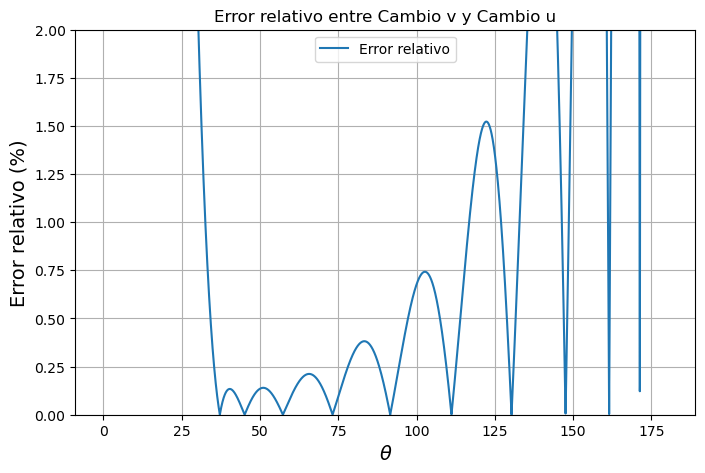

Error relativo promedio: 21.89131 %
En paso: 0.02
Tiempo de ejecución para paso = 0.02: 0.8500 segundos


## **Ejecutando con paso = 0.01...**

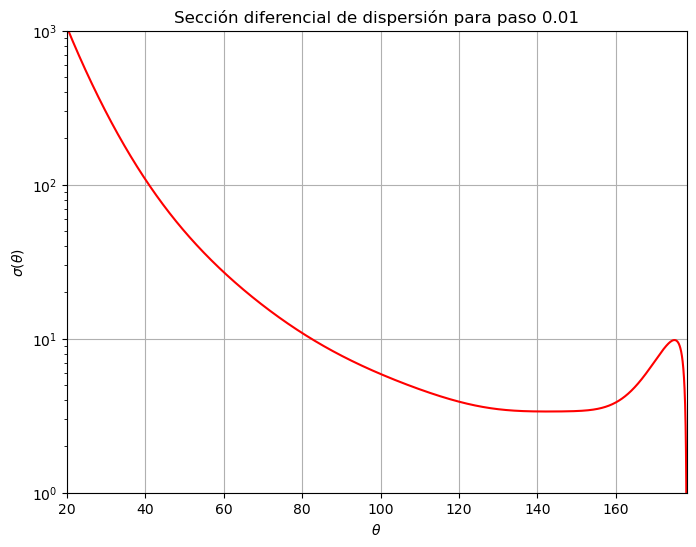

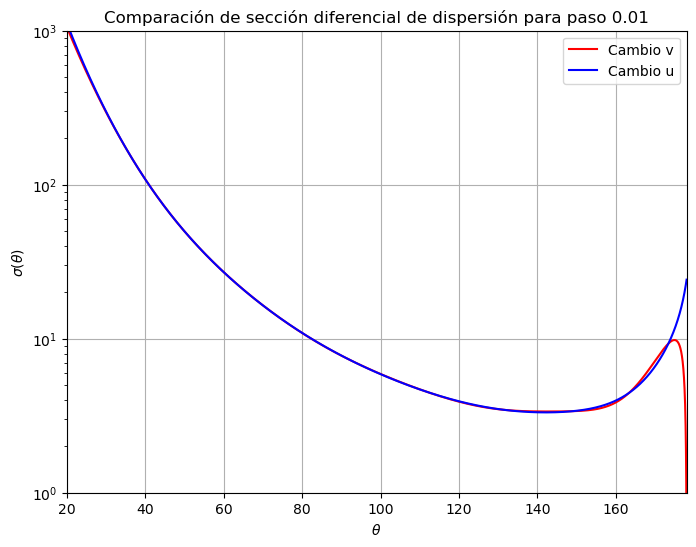

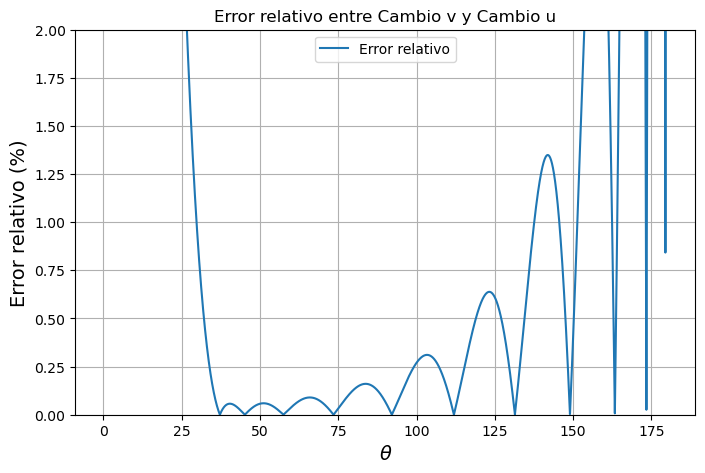

Error relativo promedio: 4.13496 %
En paso: 0.01
Tiempo de ejecución para paso = 0.01: 0.7057 segundos


## **Ejecutando con paso = 0.009...**

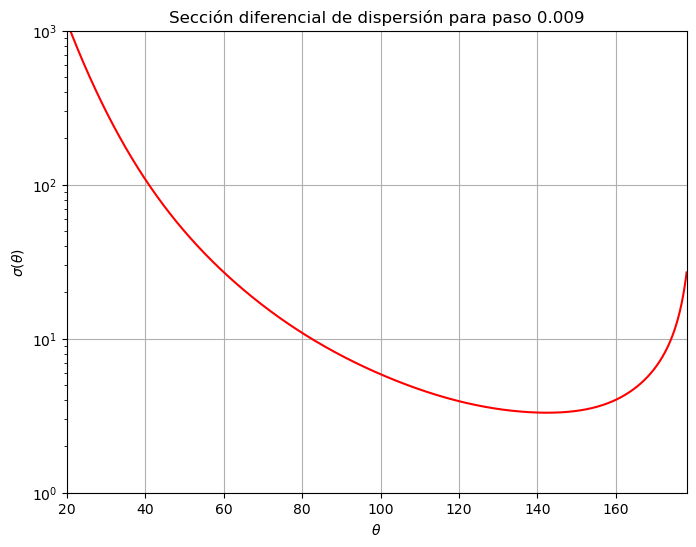

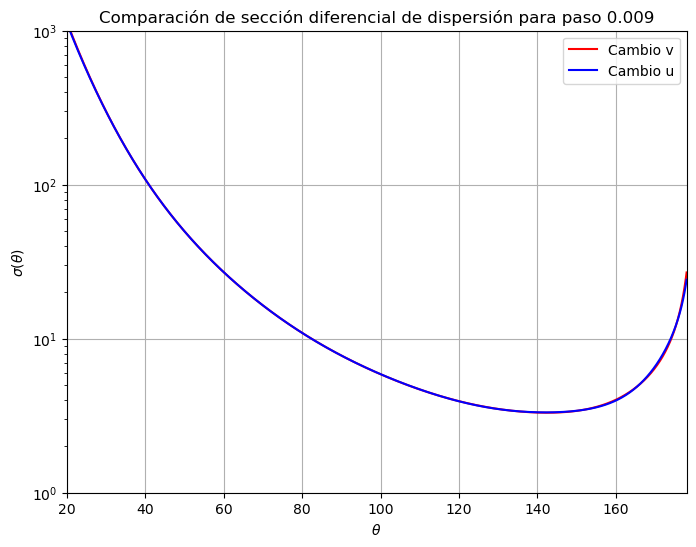

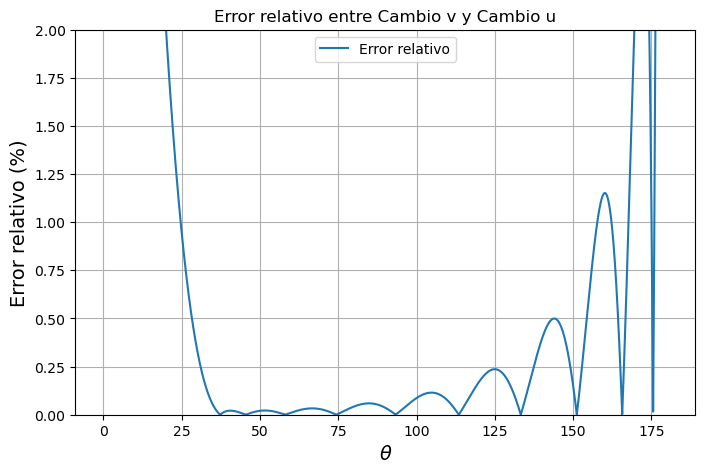

Error relativo promedio: 1.26799 %
En paso: 0.009
Tiempo de ejecución para paso = 0.009: 0.7928 segundos


## **Ejecutando con paso = 0.008...**

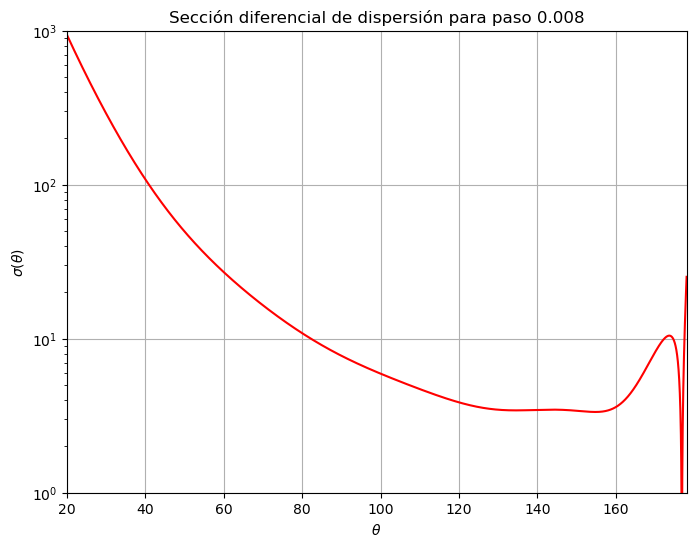

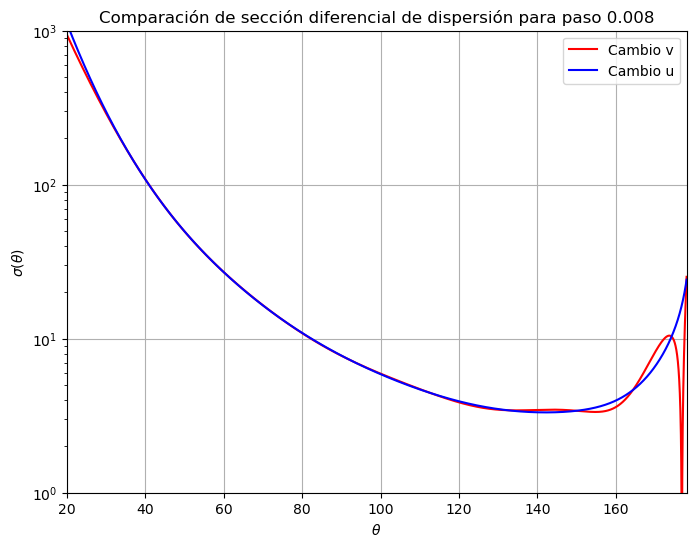

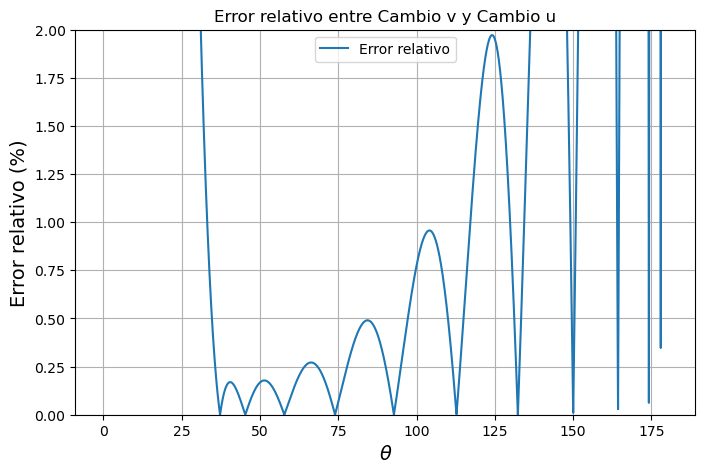

Error relativo promedio: 9.89548 %
En paso: 0.008
Tiempo de ejecución para paso = 0.008: 1.0624 segundos


## **Ejecutando con paso = 0.007...**

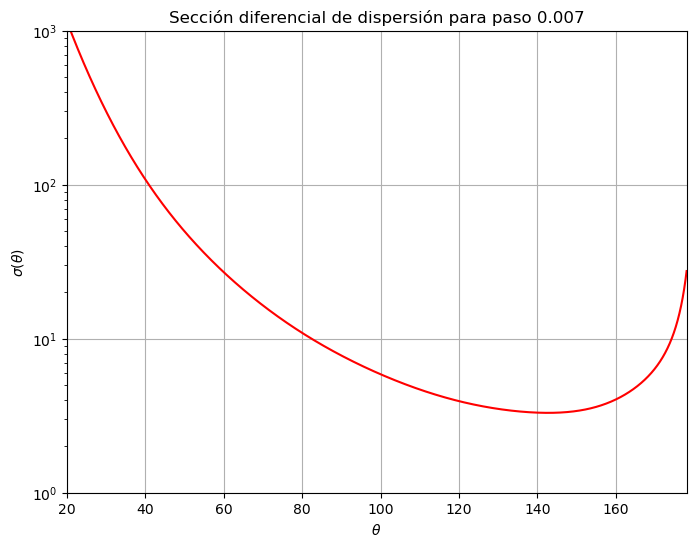

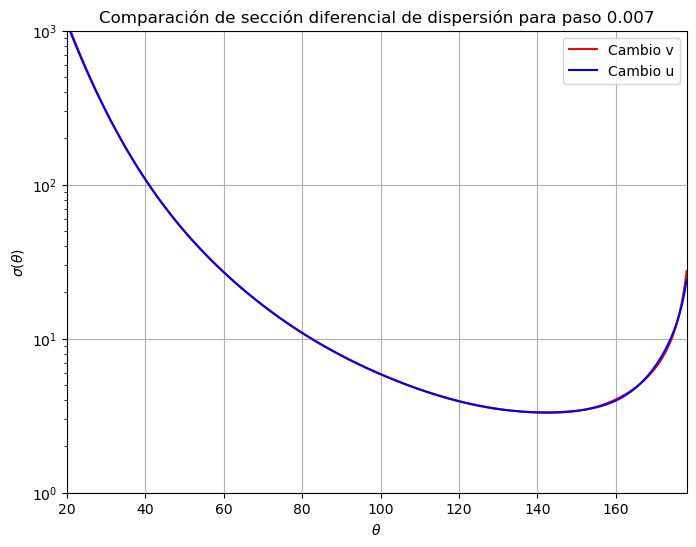

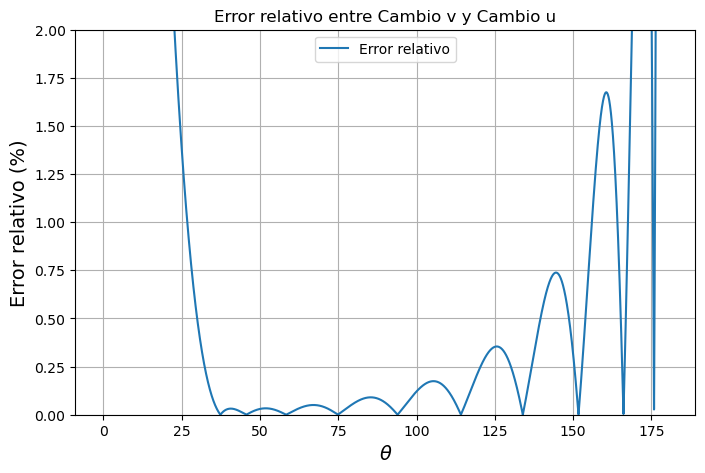

Error relativo promedio: 1.74405 %
En paso: 0.007
Tiempo de ejecución para paso = 0.007: 1.0166 segundos


## **Ejecutando con paso = 0.006...**

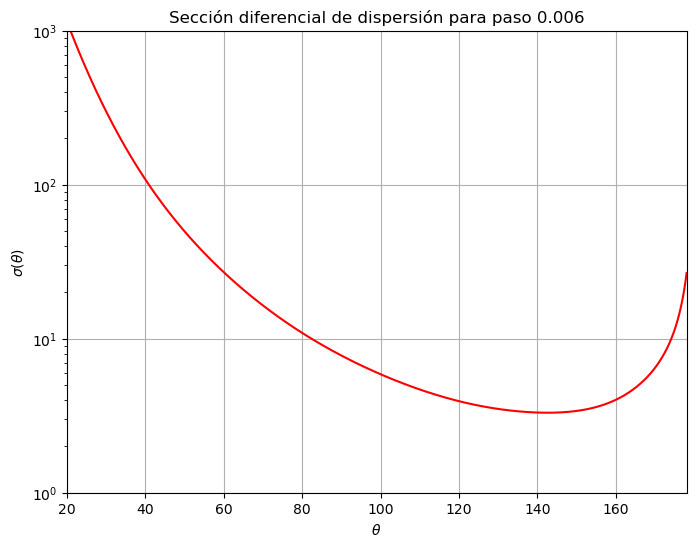

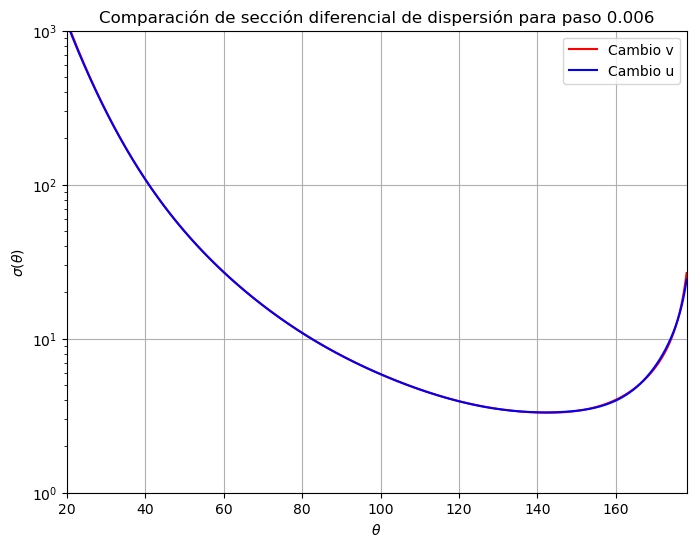

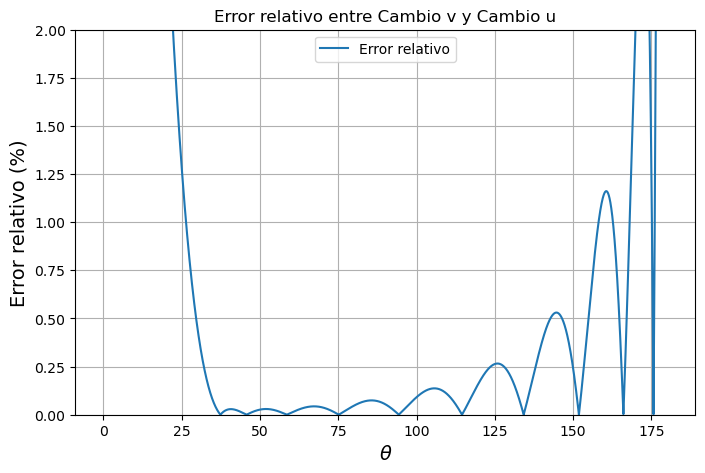

Error relativo promedio: 1.51243 %
En paso: 0.006
Tiempo de ejecución para paso = 0.006: 1.0262 segundos


## **Ejecutando con paso = 0.005...**

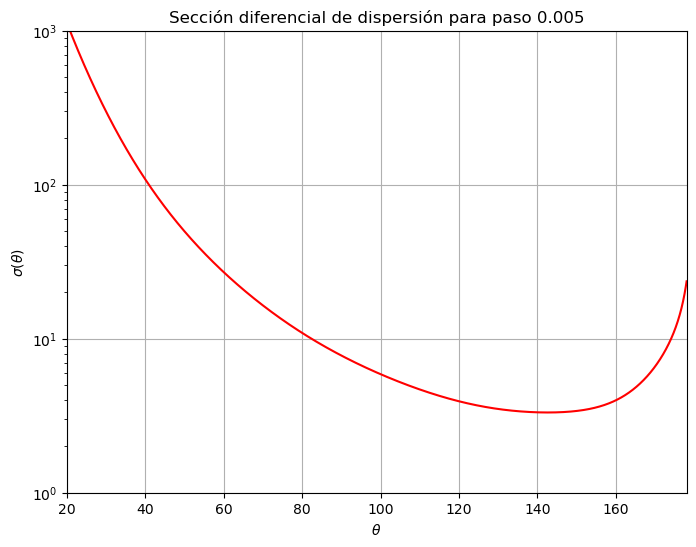

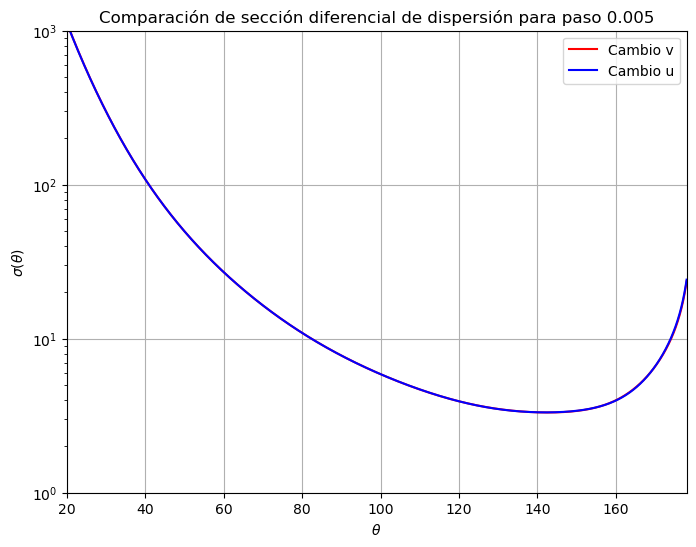

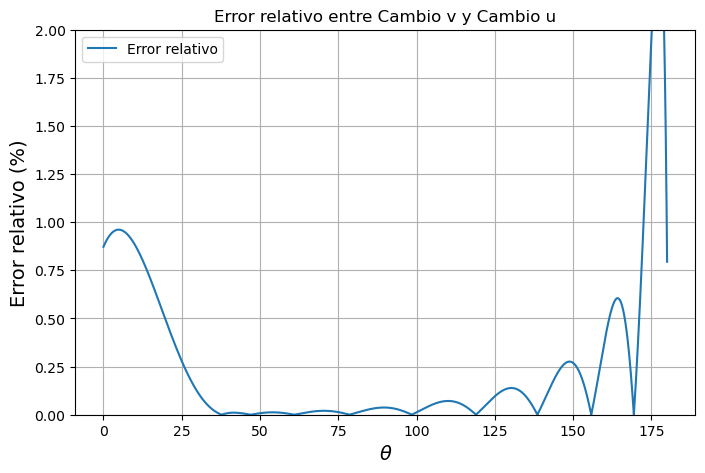

Error relativo promedio: 0.26185 %
En paso: 0.005
Tiempo de ejecución para paso = 0.005: 0.9799 segundos


## **Ejecutando con paso = 0.004...**

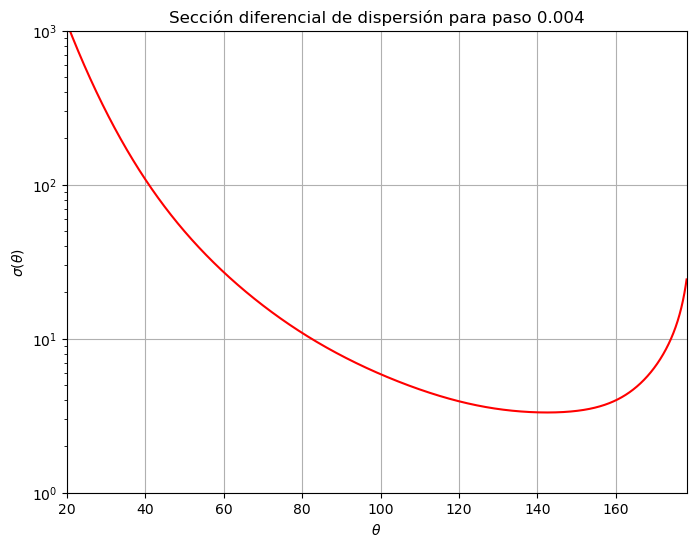

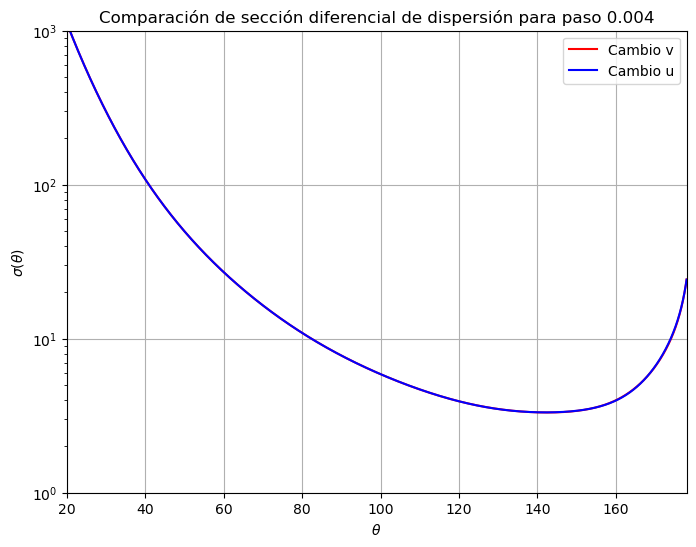

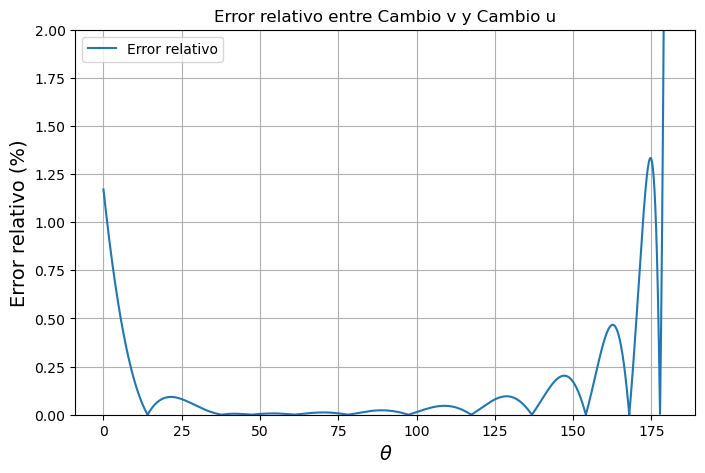

Error relativo promedio: 0.16071 %
En paso: 0.004
Tiempo de ejecución para paso = 0.004: 1.1559 segundos


## **Ejecutando con paso = 0.003...**

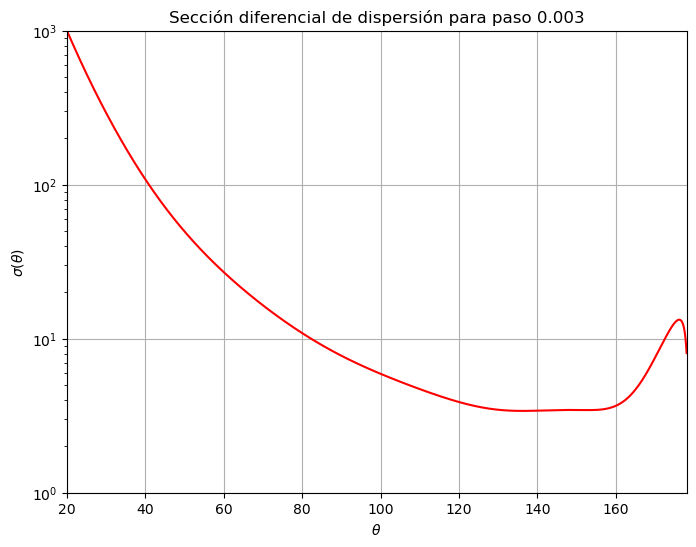

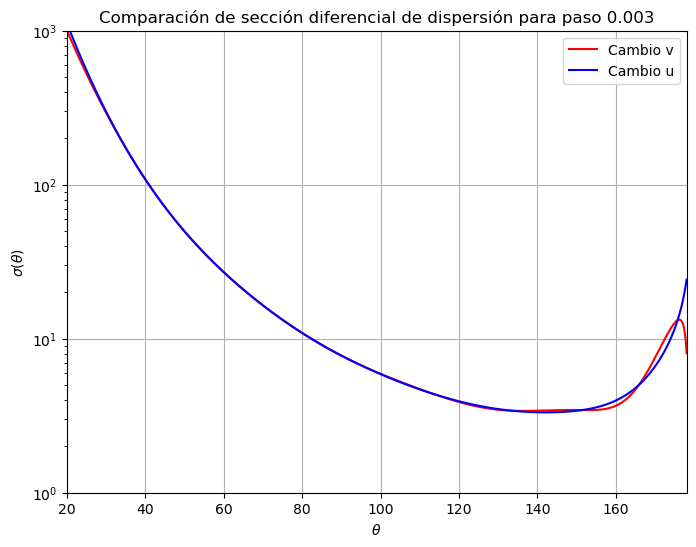

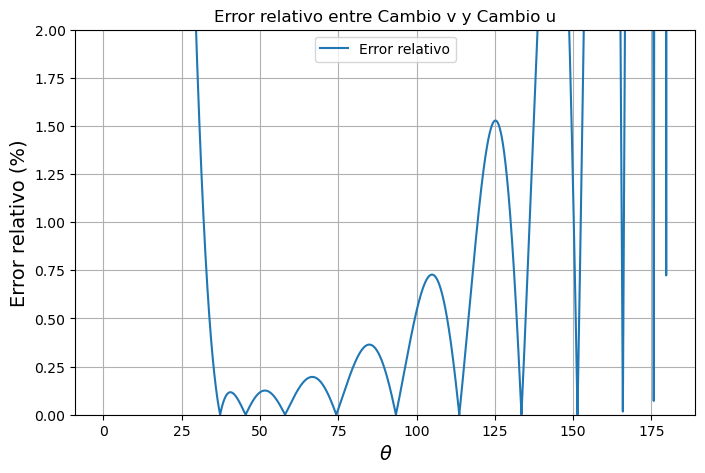

Error relativo promedio: 5.90552 %
En paso: 0.003
Tiempo de ejecución para paso = 0.003: 1.2626 segundos


## **Ejecutando con paso = 0.002...**

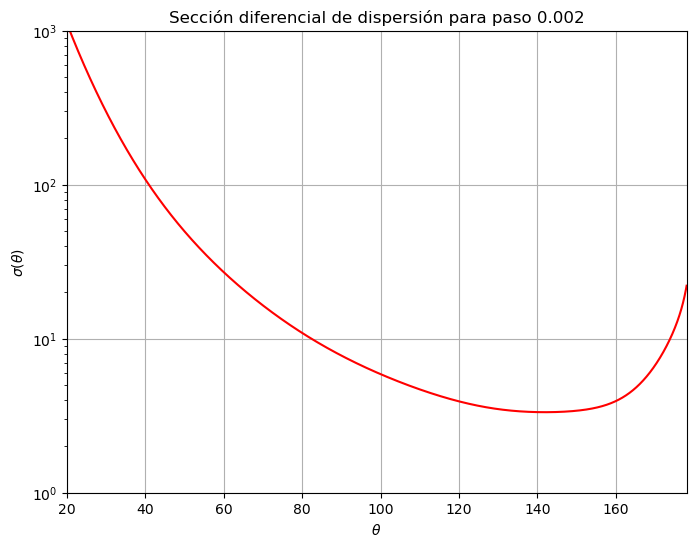

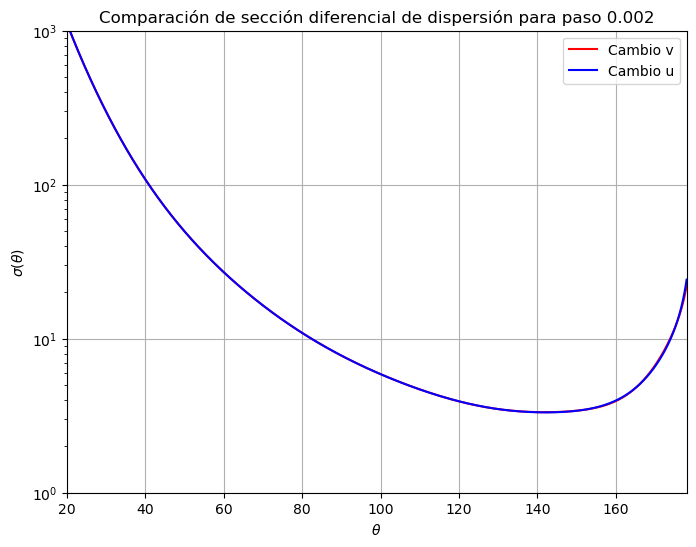

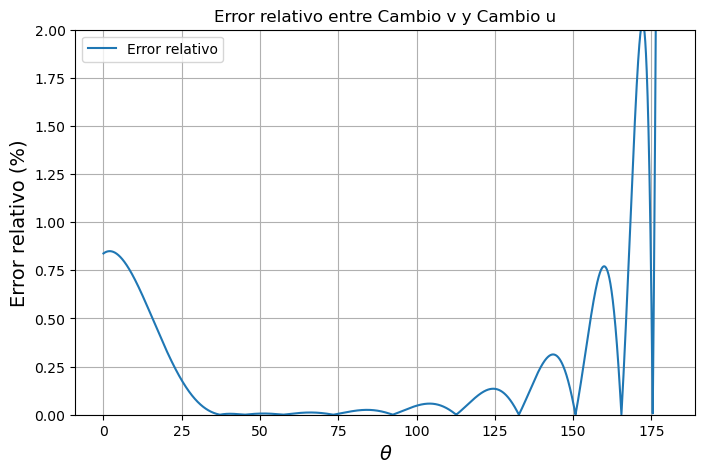

Error relativo promedio: 0.46673 %
En paso: 0.002
Tiempo de ejecución para paso = 0.002: 1.5594 segundos


## **Ejecutando con paso = 0.001...**

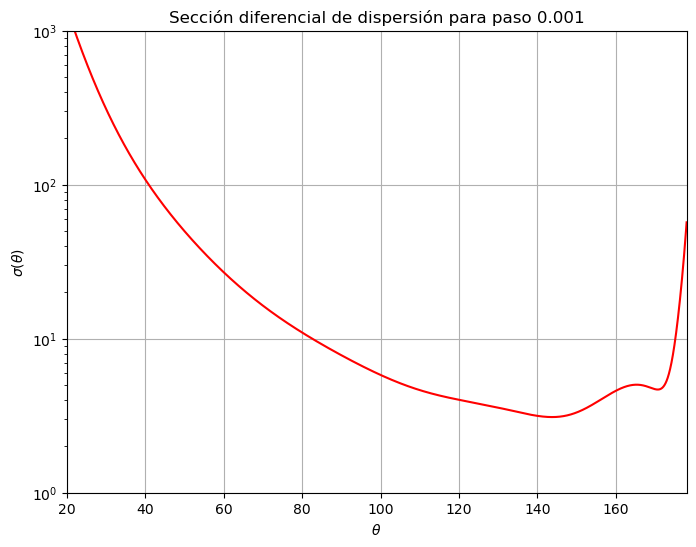

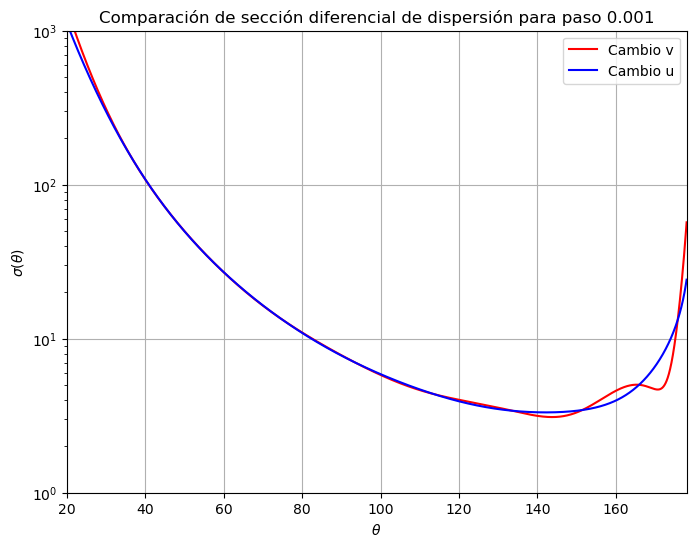

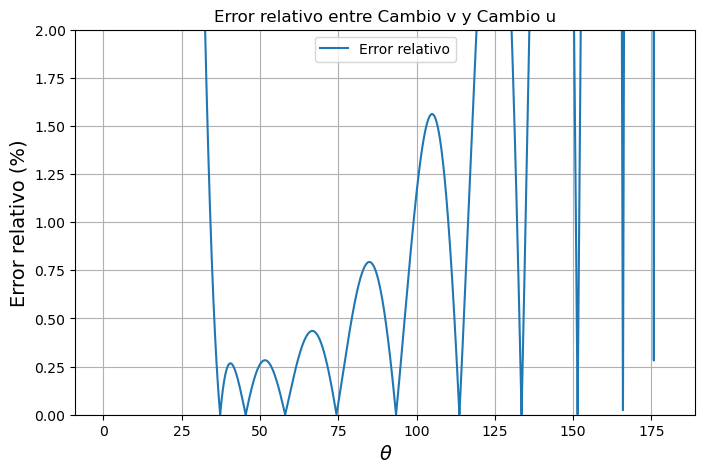

Error relativo promedio: 17.01478 %
En paso: 0.001
Tiempo de ejecución para paso = 0.001: 2.0498 segundos


## **Ejecutando con paso = 0.0009...**

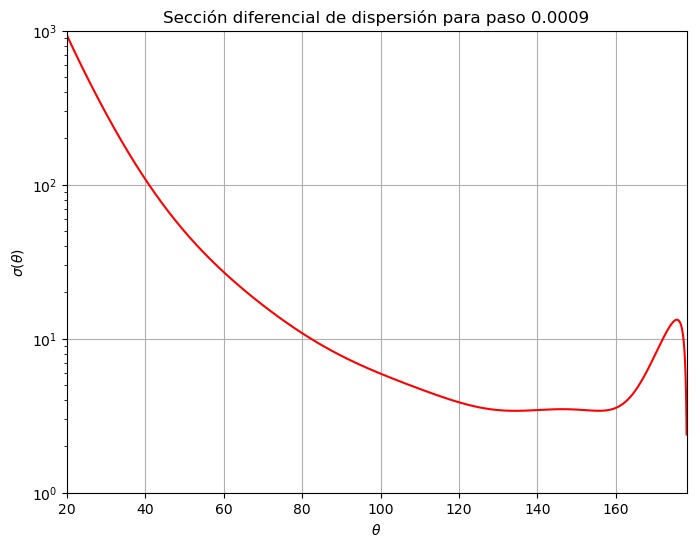

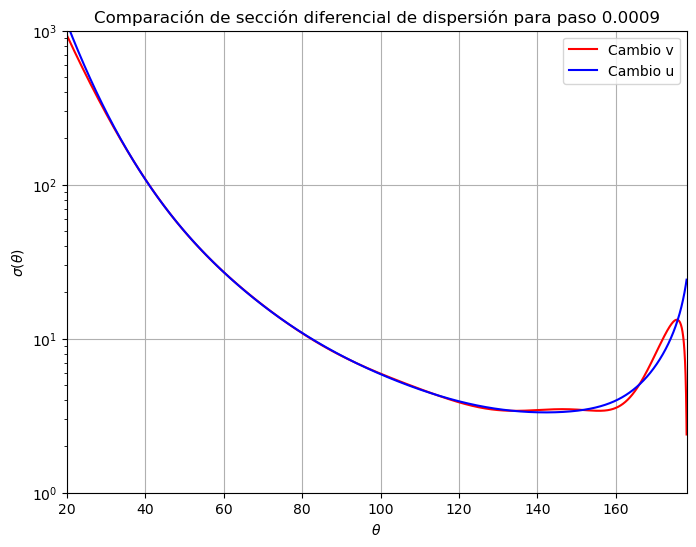

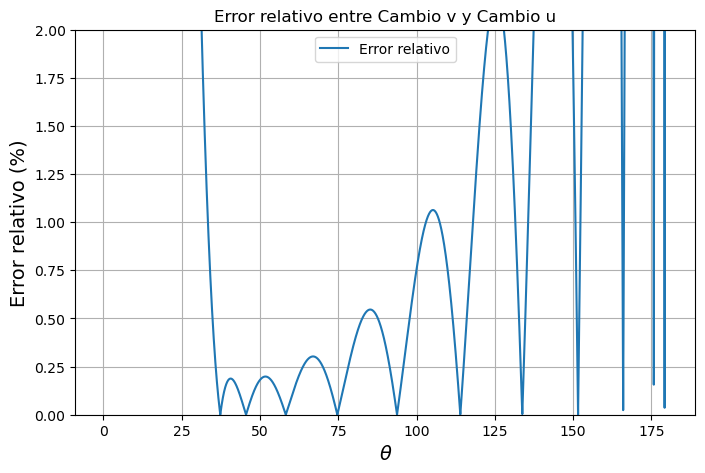

Error relativo promedio: 8.52439 %
En paso: 0.0009
Tiempo de ejecución para paso = 0.0009: 2.5682 segundos


## **Ejecutando con paso = 0.0008...**

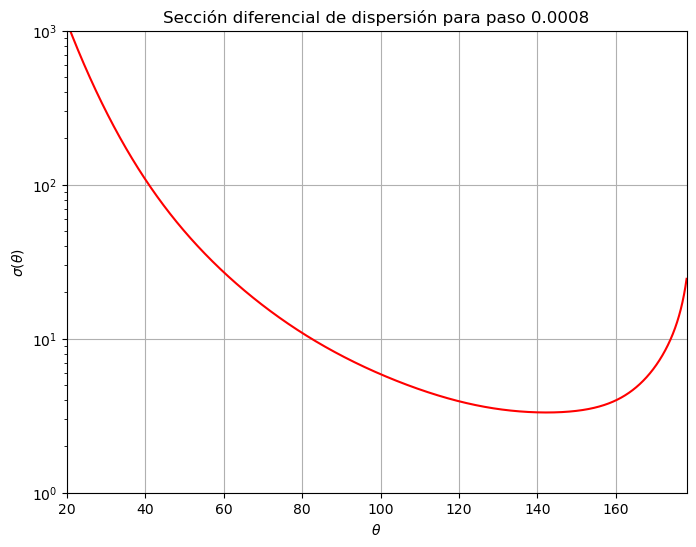

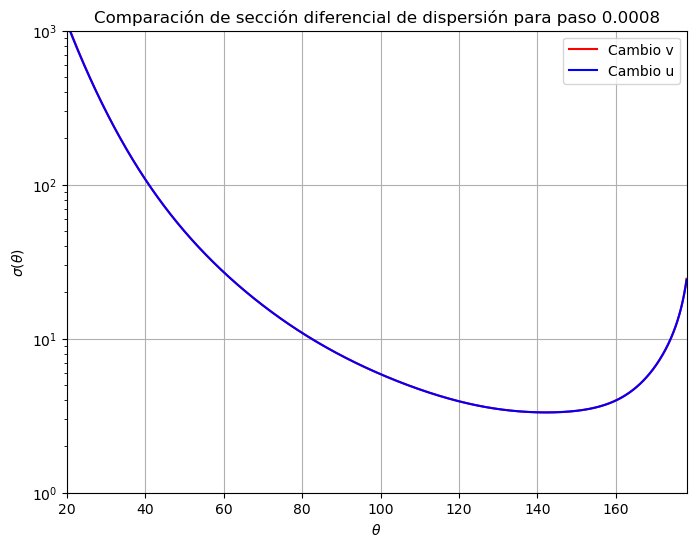

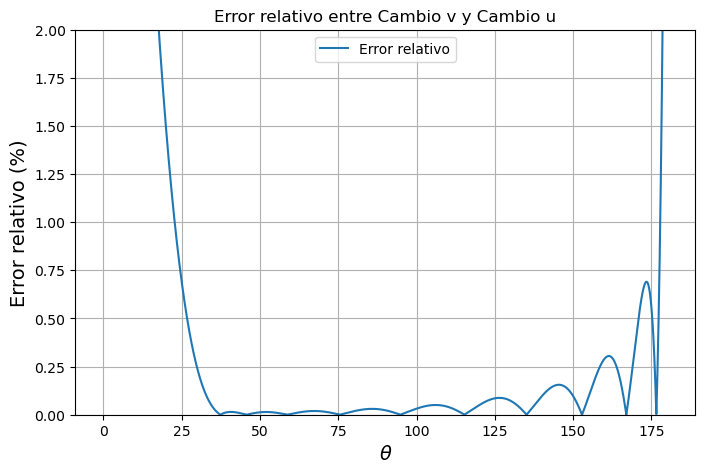

Error relativo promedio: 0.67585 %
En paso: 0.0008
Tiempo de ejecución para paso = 0.0008: 2.5607 segundos


## **Ejecutando con paso = 0.0007...**

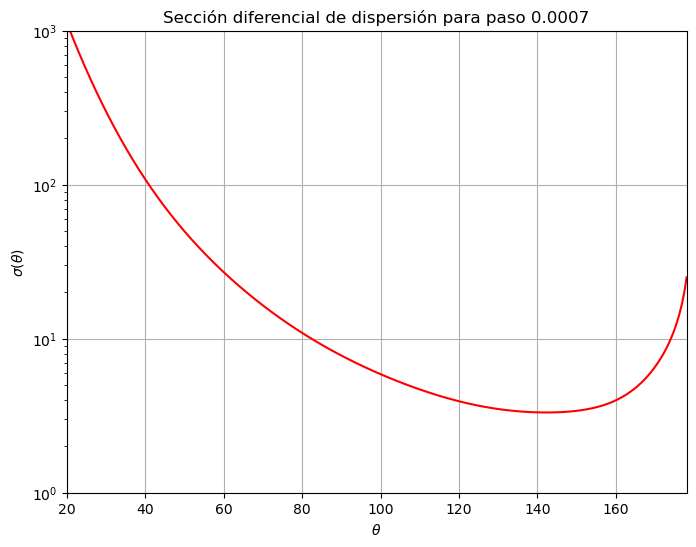

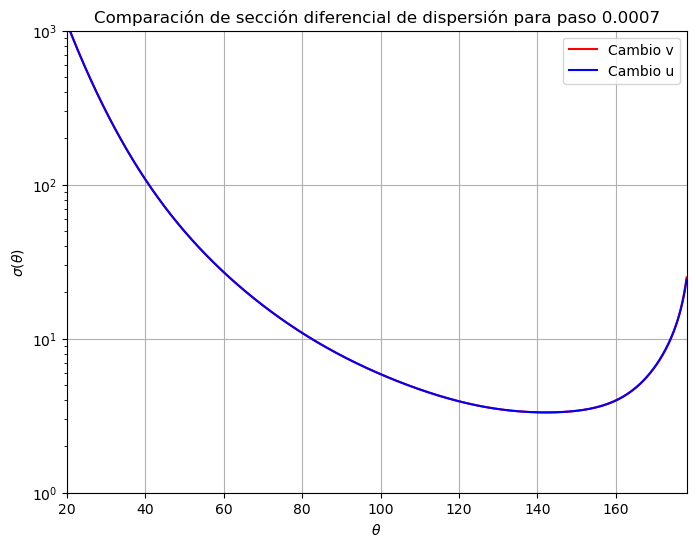

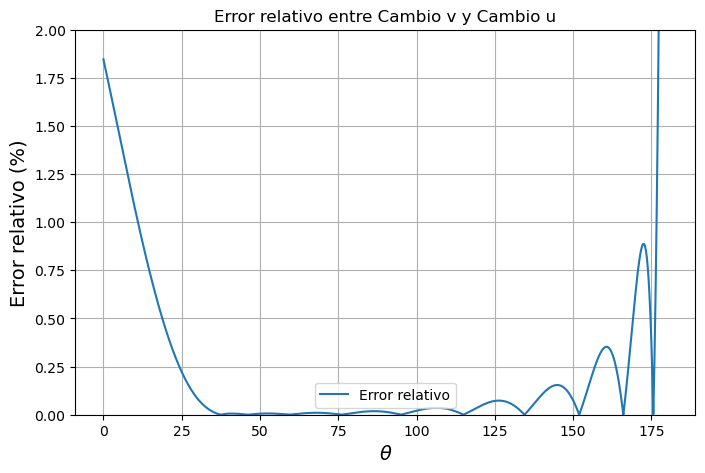

Error relativo promedio: 0.29931 %
En paso: 0.0007
Tiempo de ejecución para paso = 0.0007: 2.4815 segundos


## **Ejecutando con paso = 0.0006...**

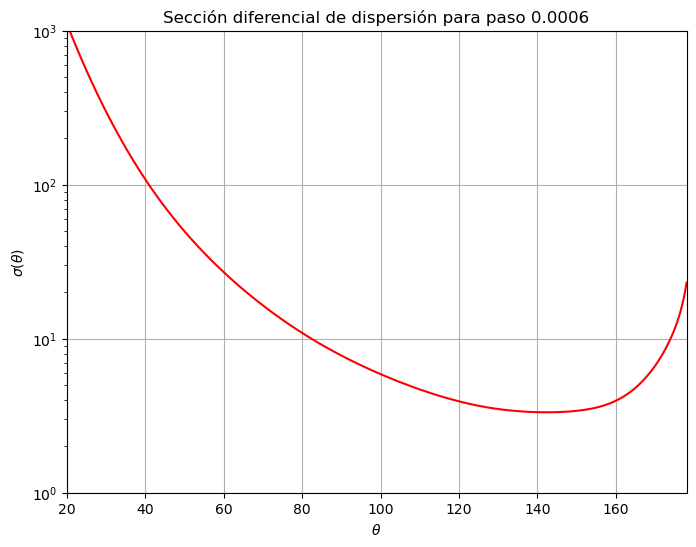

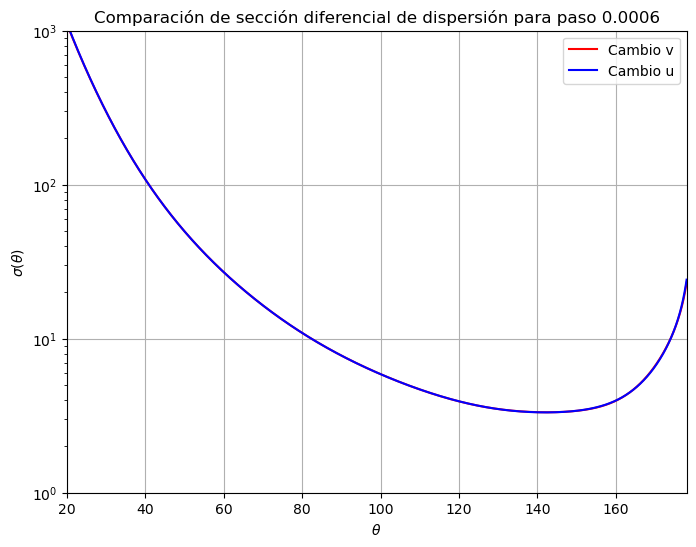

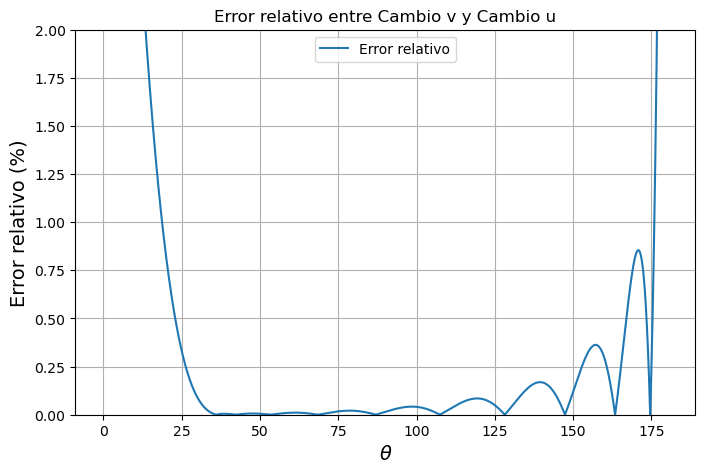

Error relativo promedio: 0.57040 %
En paso: 0.0006
Tiempo de ejecución para paso = 0.0006: 3.5802 segundos


## **Ejecutando con paso = 0.0005...**

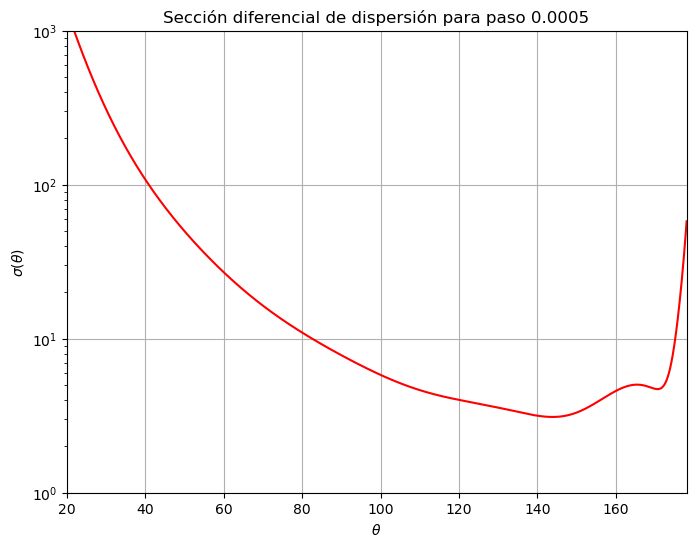

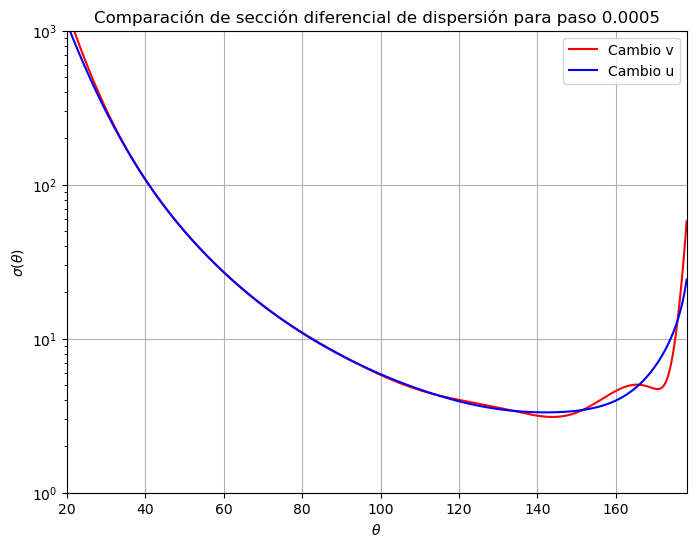

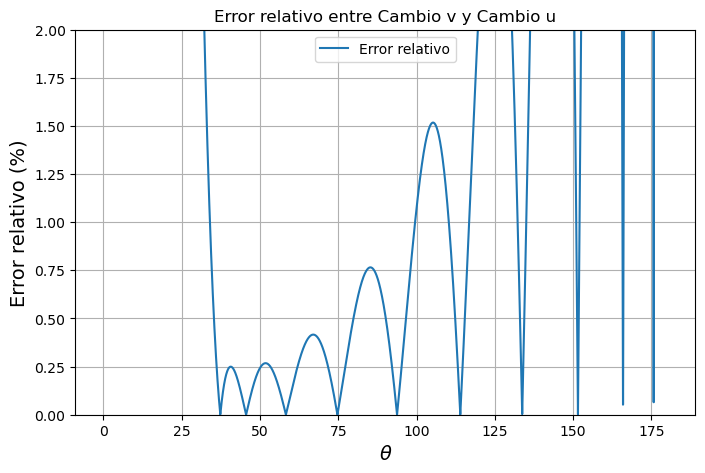

Error relativo promedio: 15.25192 %
En paso: 0.0005
Tiempo de ejecución para paso = 0.0005: 3.0174 segundos


## **Ejecutando con paso = 0.0004...**

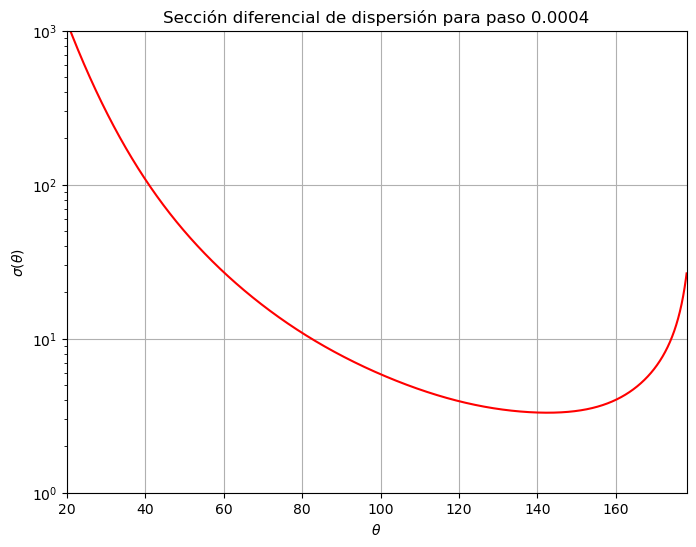

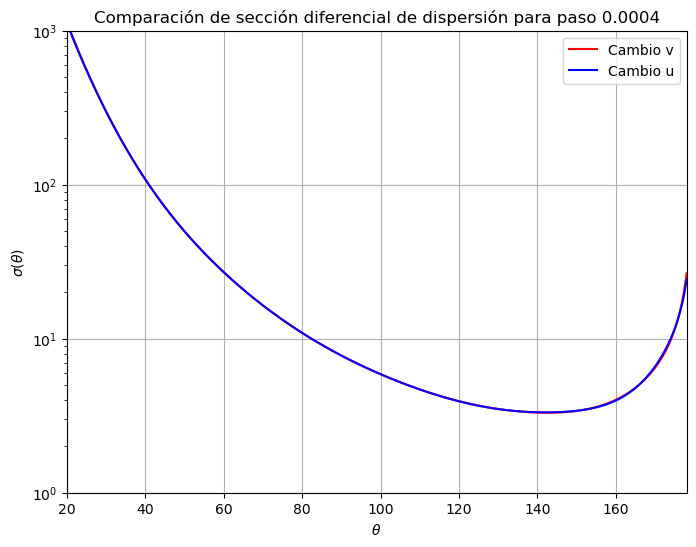

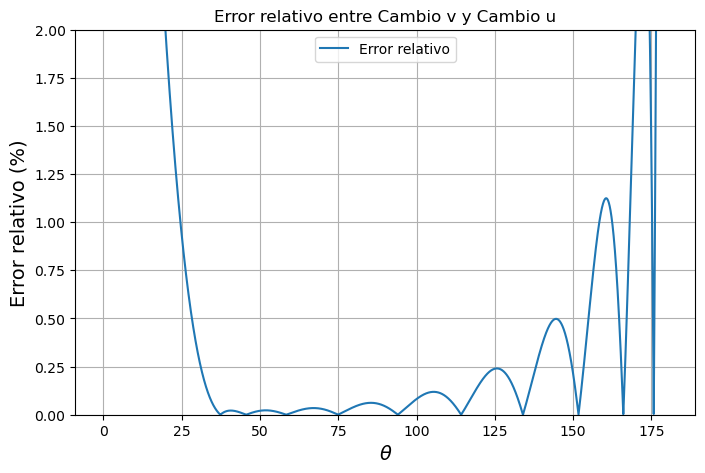

Error relativo promedio: 1.18446 %
En paso: 0.0004
Tiempo de ejecución para paso = 0.0004: 4.2284 segundos


## **Ejecutando con paso = 0.0003...**

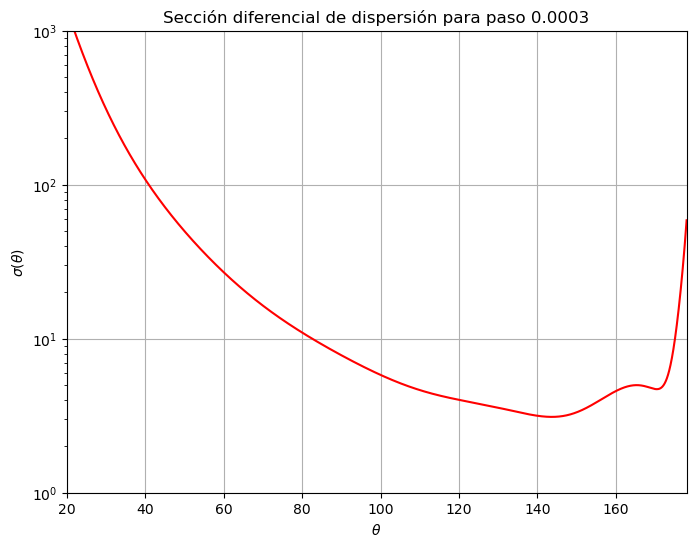

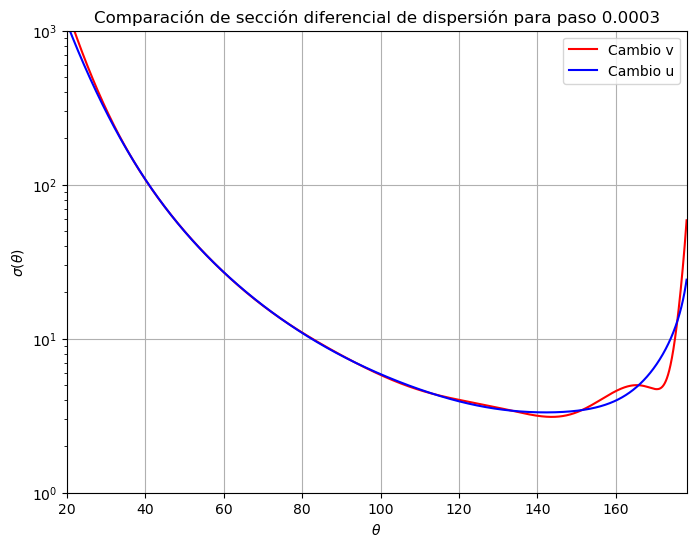

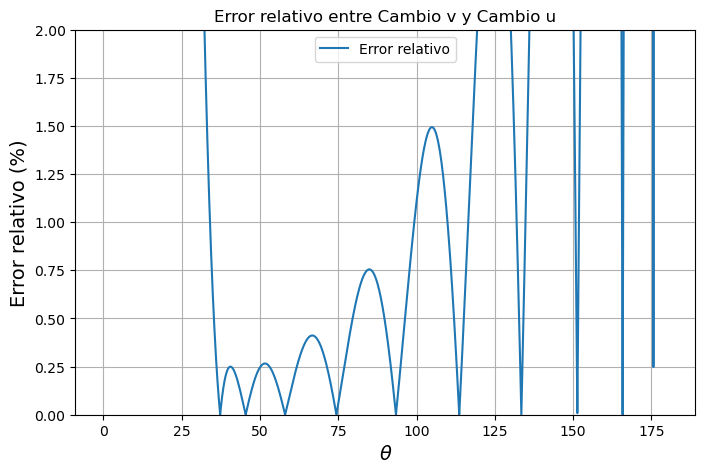

Error relativo promedio: 16.15158 %
En paso: 0.0003
Tiempo de ejecución para paso = 0.0003: 5.3591 segundos


## **Ejecutando con paso = 0.0002...**

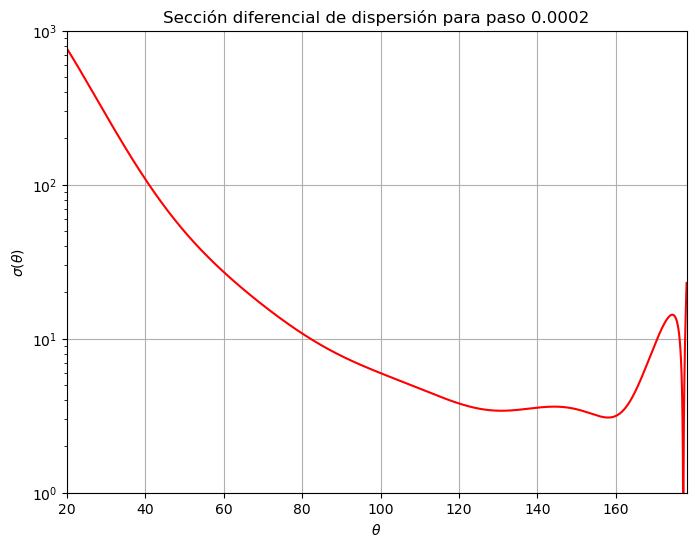

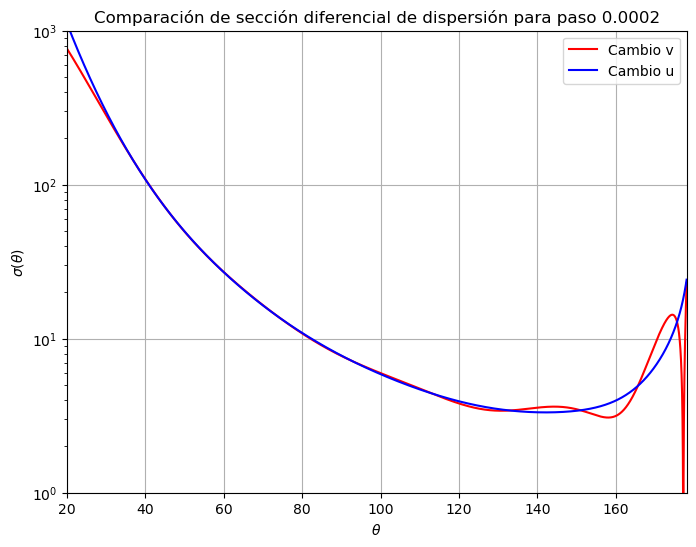

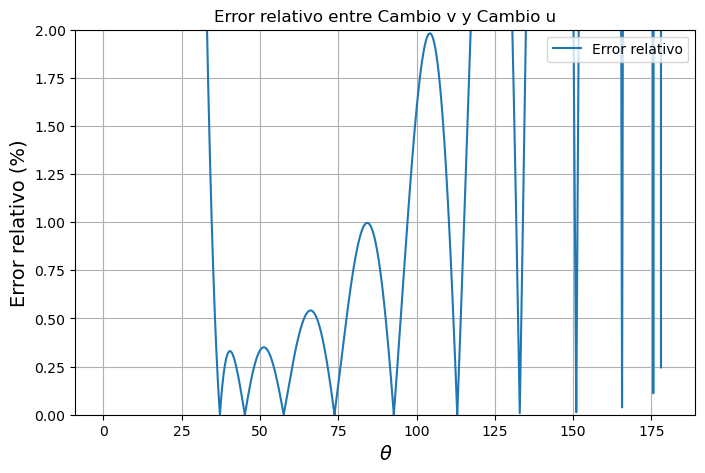

Error relativo promedio: 15.75070 %
En paso: 0.0002
Tiempo de ejecución para paso = 0.0002: 6.8717 segundos


## **Ejecutando con paso = 0.0001...**

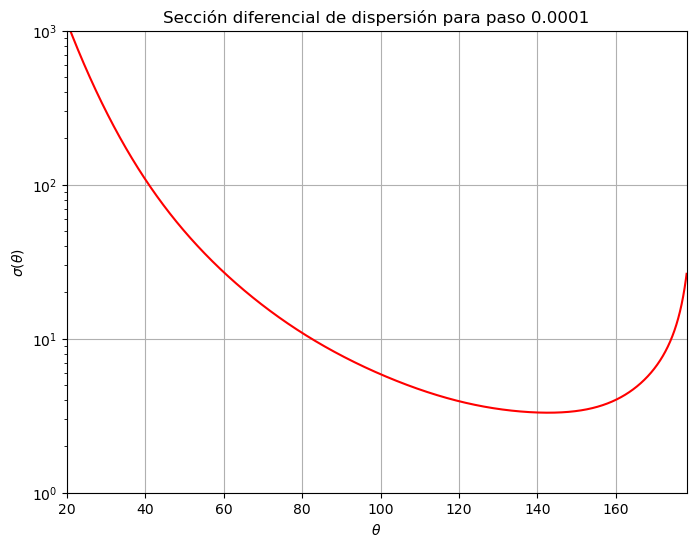

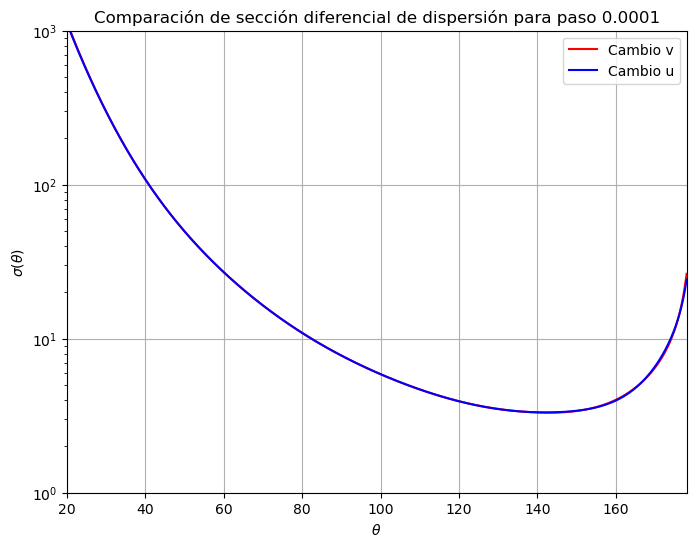

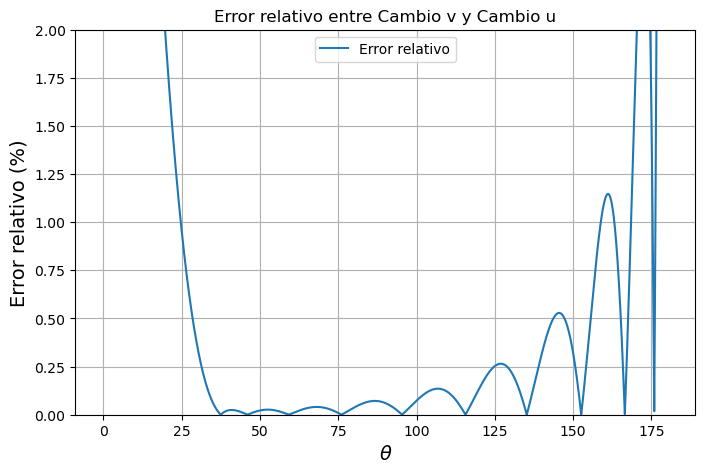

Error relativo promedio: 1.11566 %
En paso: 0.0001
Tiempo de ejecución para paso = 0.0001: 14.4382 segundos


## **Ejecutando con paso = 0.0001...**

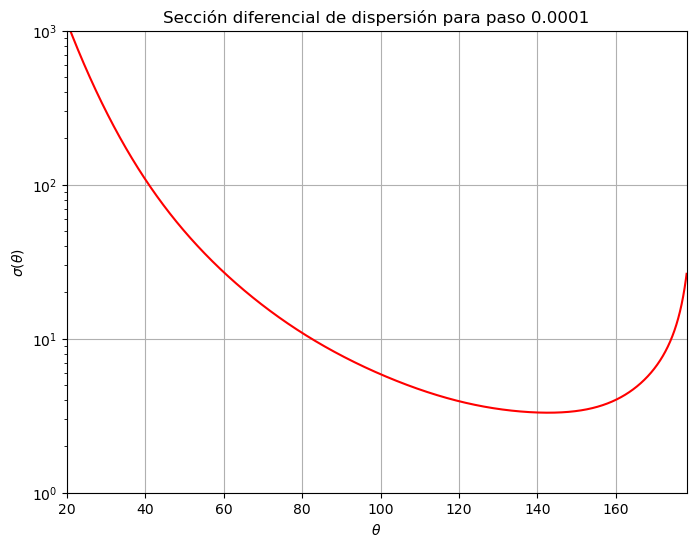

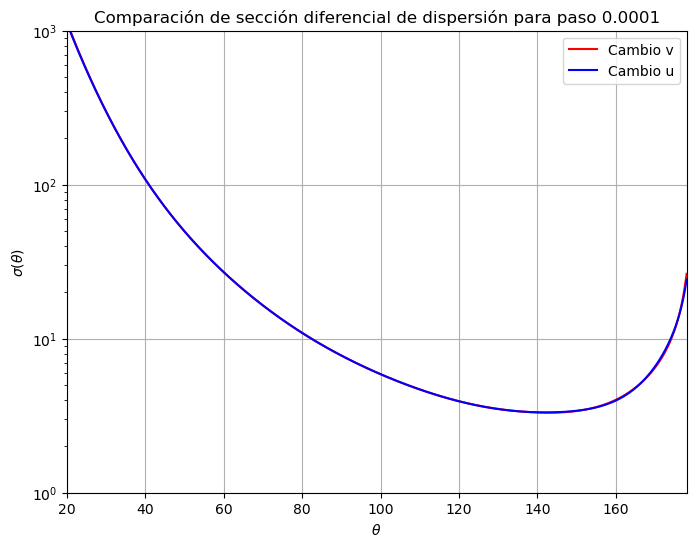

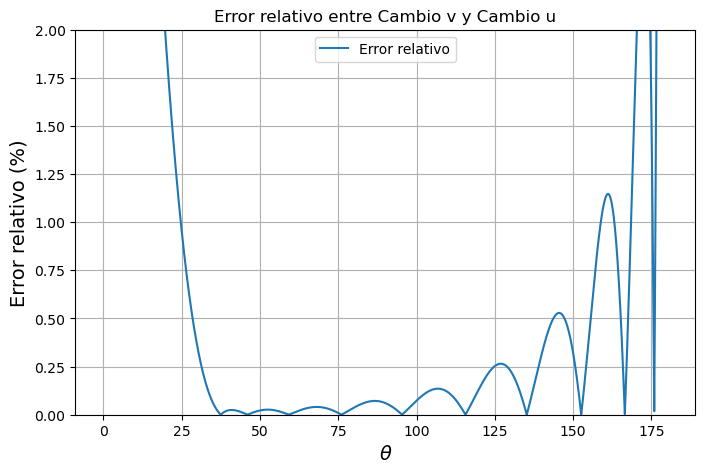

Error relativo promedio: 1.11566 %
En paso: 0.0001
Tiempo de ejecución para paso = 0.0001: 13.9928 segundos


In [14]:
resultados = []

for paso in pasos:
    display(Markdown(f"## **Ejecutando con paso = {paso}...**"))
    inicio_tiempo = time.time()
    
    error, duracion = automatizacion(paso)
    
    
    print(f"Tiempo de ejecución para paso = {paso}: {duracion:.4f} segundos")
    
    resultados.append((paso, error, duracion))

In [15]:
resultados_ordenados = sorted(resultados, key=lambda x: x[1])

# Mostramos los 3 mejores
print("\nTop 3 pasos con menor error:")
for i, (paso, error, duracion) in enumerate(resultados_ordenados[:3], start=1):
    print(f"{i}. Paso: {paso}, Error: {error:.4f}, Tiempo: {duracion:.2f} segundos")


Top 3 pasos con menor error:
1. Paso: 0.004, Error: 0.0016, Tiempo: 1.16 segundos
2. Paso: 0.005, Error: 0.0026, Tiempo: 0.98 segundos
3. Paso: 0.0007, Error: 0.0030, Tiempo: 2.48 segundos
